# Notebook - Find best Drug compound for `Bacillus Anthracis` bacteria. This bacteria is responsible for anthrax disease.

In this notebook, we demonstrate the use of MACAW embeddings to model binding affinity to a protein receptor of pharmacological interest. MACAW embeddings are then applied to identify promising candidate molecules in a custom virtual library.

In [196]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [197]:
import csv
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole 
import seaborn as sns
from joblib import load
from PIL import Image
import pickle
import gc

sys.path.append('../')

import macaw
print(macaw.__version__)
from macaw import *

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['figure.dpi'] = 96
matplotlib.rcParams['savefig.dpi'] = 600

%run "./plotting.py"

1.0.1


In [198]:
%config InlineBackend.figure_format = 'retina'

## 1. Regression Target: pPotency

### 1.1 Data preparation

In [199]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
resultsDir = os.path.join(dataDir, 'Results/')
DORANETmoleculesDataDir = os.path.join(dataDir, 'DORAnet_molecules/')
saveDir = os.path.join(resultsDir, "Bacillus_anthracis_bestMACAW/")
ARTresultsDir = os.path.join(dataDir, 'Results/Bacillus_anthracis_bestMACAW/')
os.makedirs(saveDir, exist_ok=True)

In [150]:
allBacteriaData_chEMBL = pd.read_csv(modelBuildingDataDir + 'allBacteriaData_chEMBL_uM.csv')

In [151]:
allBacteriaData_chEMBL

,Unnamed: 0,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,...,ro5_violations,Target ChEMBL ID,Target Name,Target Organism,Virus,value_uM,pPotency,is_convertible_to_uM,potency_family,pPotencyMid
0,1,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,C17H18FN3O3,MYSWGUAQZAJSOK-UHFFFAOYSA-N,InChI=1S/C17H18FN3O3/c18-13-7-11-14(8-15(13)20...,331.35,Small molecule,0.25,ug.mL-1,...,0.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,5.623413e+05,0.250000,True,MIC,0.250000
1,2,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,C26H21ClN2O3,KEINEPLOMWOUNE-XNTDXEJSSA-N,InChI=1S/C26H21ClN2O3/c1-31-22-13-14-23(25(16-...,444.92,Small molecule,100.00,ug.mL-1,...,1.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,1.000000e-94,100.000000,True,MIC,100.000000
2,3,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,C40H59FN10O14,VETOBWPFYDUOPP-FFKZLMLRSA-N,InChI=1S/C40H59FN10O14/c41-21-9-19-24(51(18-1-...,922.97,Small molecule,1.50,ug.mL-1,...,3.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,3.162278e+04,1.500000,True,MIC,1.500000
3,4,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,C16H12N6O5,DGJBCVGFPFQIOC-CAOOACKPSA-N,InChI=1S/C16H12N6O5/c23-16(19-17-8-11-2-1-3-13...,368.31,Small molecule,16.00,ug.mL-1,...,0.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,1.000000e-10,16.000000,True,MIC,16.000000
4,5,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,C18H14ClN5O4S,SJWDBKWBFHCWPA-UHFFFAOYSA-N,InChI=1S/C18H14ClN5O4S/c19-13-3-1-11(2-4-13)18...,431.86,Small molecule,16.00,ug.mL-1,...,0.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,1.000000e-10,16.000000,True,MIC,16.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163417,313296,CHEMBL4227290,CCCCCCCSSC(=S)N(CC)CC,C12H25NS3,LGZOHACUFLJANX-UHFFFAOYSA-N,InChI=1S/C12H25NS3/c1-4-7-8-9-10-11-15-16-12(1...,279.54,Small molecule,32000.00,nM,...,0.0,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,3.200000e+01,4.494850,True,MIC,4.494850
163418,313298,CHEMBL1255631,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,C145H210N28O21,QNANZYFCKTWPTJ-WSPVJQGRSA-N,InChI=1S/C145H210N28O21/c1-93(174)154-76-36-65...,2681.45,Small molecule,46600.00,nM,...,NaN,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,4.660000e+01,4.331614,True,MIC,4.331614
163419,313304,CHEMBL5276443,CC(C)(CNc1ccc(C(N)=O)cn1)c1ccccc1,C16H19N3O,XVNKQYMDQJGTEQ-UHFFFAOYSA-N,"InChI=1S/C16H19N3O/c1-16(2,13-6-4-3-5-7-13)11-...",269.35,NaN,256.00,ug.mL-1,...,0.0,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,1.000000e-250,256.000000,True,MIC,256.000000
163420,313309,CHEMBL1916867,CSC(=S)N/N=C/c1ccccc1O,C9H10N2OS2,SATLYQNFXURMCO-UXBLZVDNSA-N,InChI=1S/C9H10N2OS2/c1-14-9(13)11-10-6-7-4-2-3...,226.33,Small molecule,4000.00,nM,...,0.0,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,4.000000e+00,5.397940,True,IC/EC,5.397940


### Filter columns

In [152]:
allBacteriaData_chEMBL = allBacteriaData_chEMBL.filter(
    items=["molecule_chembl_id", "smiles", "value_uM", "pPotency", "Virus"]
)
allBacteriaData_chEMBL

,molecule_chembl_id,smiles,value_uM,pPotency,Virus
0,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,5.623413e+05,0.250000,Bacillus_subtilisData_chEMBL_combined.csv
1,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,1.000000e-94,100.000000,Bacillus_subtilisData_chEMBL_combined.csv
2,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,3.162278e+04,1.500000,Bacillus_subtilisData_chEMBL_combined.csv
3,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,1.000000e-10,16.000000,Bacillus_subtilisData_chEMBL_combined.csv
4,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,1.000000e-10,16.000000,Bacillus_subtilisData_chEMBL_combined.csv
...,...,...,...,...,...
163417,CHEMBL4227290,CCCCCCCSSC(=S)N(CC)CC,3.200000e+01,4.494850,Yersinia_pestisData_chEMBL_combined.csv
163418,CHEMBL1255631,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,4.660000e+01,4.331614,Yersinia_pestisData_chEMBL_combined.csv
163419,CHEMBL5276443,CC(C)(CNc1ccc(C(N)=O)cn1)c1ccccc1,1.000000e-250,256.000000,Yersinia_pestisData_chEMBL_combined.csv
163420,CHEMBL1916867,CSC(=S)N/N=C/c1ccccc1O,4.000000e+00,5.397940,Yersinia_pestisData_chEMBL_combined.csv


### Remove the trailing 'Data_chEMBL_combined.csv' from each entry in the 'Virus' column

In [153]:
allBacteriaData_chEMBL['Virus'] = allBacteriaData_chEMBL['Virus'].str.replace('Data_chEMBL_combined.csv', '', regex=False)
allBacteriaData_chEMBL.rename(columns={'Virus': 'BacteriaClassifier'}, inplace=True)
allBacteriaData_chEMBL

,molecule_chembl_id,smiles,value_uM,pPotency,BacteriaClassifier
0,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,5.623413e+05,0.250000,Bacillus_subtilis
1,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,1.000000e-94,100.000000,Bacillus_subtilis
2,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,3.162278e+04,1.500000,Bacillus_subtilis
3,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,1.000000e-10,16.000000,Bacillus_subtilis
4,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,1.000000e-10,16.000000,Bacillus_subtilis
...,...,...,...,...,...
163417,CHEMBL4227290,CCCCCCCSSC(=S)N(CC)CC,3.200000e+01,4.494850,Yersinia_pestis
163418,CHEMBL1255631,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,4.660000e+01,4.331614,Yersinia_pestis
163419,CHEMBL5276443,CC(C)(CNc1ccc(C(N)=O)cn1)c1ccccc1,1.000000e-250,256.000000,Yersinia_pestis
163420,CHEMBL1916867,CSC(=S)N/N=C/c1ccccc1O,4.000000e+00,5.397940,Yersinia_pestis


### Keep only data for `Bacillus_anthracis` bacteria

In [154]:
BacillusAnthracisData_chEMBL = allBacteriaData_chEMBL[allBacteriaData_chEMBL['BacteriaClassifier'] == 'Bacillus_anthracis']
BacillusAnthracisData_chEMBL

,molecule_chembl_id,smiles,value_uM,pPotency,BacteriaClassifier
162379,CHEMBL1257070,Cc1oc(=O)oc1COC(=O)C1=C([C@H]2CCCO2)S[C@@H]2[C...,7.585776e+05,0.12,Bacillus_anthracis
162380,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,1.000000e+04,2.00,Bacillus_anthracis
162381,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,1.000000e+04,2.00,Bacillus_anthracis
162382,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,1.000000e+04,2.00,Bacillus_anthracis
162383,CHEMBL529,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,1.000000e+04,2.00,Bacillus_anthracis
...,...,...,...,...,...
163230,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,1.000000e+01,5.00,Bacillus_anthracis
163231,CHEMBL1922604,CC(=O)N(O)CCCP(=O)([O-])O.[Na+],1.000000e-44,50.00,Bacillus_anthracis
163232,CHEMBL1922611,CC(=O)N(O)CCCP(=O)(OC(C)OC(=O)OC(C)(C)C)OC(C)O...,1.000000e-194,200.00,Bacillus_anthracis
163233,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,1.584893e-02,7.80,Bacillus_anthracis


### Remove `Basidalin` from training set

In [155]:
#Remdesivir_SMILES = 'CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1'
Basidalin_SMILES='C1=C(/C(=C\C=O)/OC1=O)N'

# Canonicalize the Remdesivir SMILES
remMol = Chem.MolFromSmiles(Basidalin_SMILES)
remCan = Chem.MolToSmiles(remMol, canonical=True)

# Canonicalize all SMILES in your dataframe
BacillusAnthracisData_chEMBL["canonical_smiles"] = (
    BacillusAnthracisData_chEMBL["smiles"]
    .apply(lambda s: Chem.MolToSmiles(Chem.MolFromSmiles(s), canonical=True)
          if Chem.MolFromSmiles(s) else None)
)

# Remove rows matching Remdesivir
mask = BacillusAnthracisData_chEMBL["canonical_smiles"] != remCan
BacillusAnthracisData_chEMBL_clean = BacillusAnthracisData_chEMBL[mask].copy()

print("Original shape of data frame:", len(BacillusAnthracisData_chEMBL))
print("After removing Basidalin:", len(BacillusAnthracisData_chEMBL_clean))
BacillusAnthracisData_chEMBL = BacillusAnthracisData_chEMBL_clean.copy()

Original shape of data frame: 856
After removing Basidalin: 856


### Rename columns

In [156]:
BacillusAnthracisData_chEMBL = BacillusAnthracisData_chEMBL.rename(columns={
    "molecule_chembl_id": "compound_id",
    "smiles": "Smiles",
    #"pPotencyMid" : "pPotency",
})
BacillusAnthracisData_chEMBL.head()

,compound_id,Smiles,value_uM,pPotency,BacteriaClassifier,canonical_smiles
162379,CHEMBL1257070,Cc1oc(=O)oc1COC(=O)C1=C([C@H]2CCCO2)S[C@@H]2[C...,758577.575029,0.12,Bacillus_anthracis,Cc1oc(=O)oc1COC(=O)C1=C([C@H]2CCCO2)S[C@@H]2[C...
162380,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,10000.000000,2.00,Bacillus_anthracis,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...
162381,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,10000.000000,2.00,Bacillus_anthracis,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...
162382,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,10000.000000,2.00,Bacillus_anthracis,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...
162383,CHEMBL529,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,10000.000000,2.00,Bacillus_anthracis,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...


### Add `ID` column to left

In [157]:
BacillusAnthracisData_chEMBL.insert(0, 'ID', range(1, len(BacillusAnthracisData_chEMBL) + 1))
BacillusAnthracisData_chEMBL.head()

,ID,compound_id,Smiles,value_uM,pPotency,BacteriaClassifier,canonical_smiles
162379,1,CHEMBL1257070,Cc1oc(=O)oc1COC(=O)C1=C([C@H]2CCCO2)S[C@@H]2[C...,758577.575029,0.12,Bacillus_anthracis,Cc1oc(=O)oc1COC(=O)C1=C([C@H]2CCCO2)S[C@@H]2[C...
162380,2,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,10000.000000,2.00,Bacillus_anthracis,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...
162381,3,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,10000.000000,2.00,Bacillus_anthracis,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...
162382,4,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,10000.000000,2.00,Bacillus_anthracis,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...
162383,5,CHEMBL529,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,10000.000000,2.00,Bacillus_anthracis,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...


### Add another filer to keep only these columns: `ID`, `compound_id`,	`Smiles`, `pPotency`, `BacteriaClassifier`

In [158]:
BacillusAnthracisData_chEMBL = BacillusAnthracisData_chEMBL.filter(
    items=["ID", "compound_id", "Smiles", "pPotency", "BacteriaClassifier"]
)
BacillusAnthracisData_chEMBL.head()

,ID,compound_id,Smiles,pPotency,BacteriaClassifier
162379,1,CHEMBL1257070,Cc1oc(=O)oc1COC(=O)C1=C([C@H]2CCCO2)S[C@@H]2[C...,0.12,Bacillus_anthracis
162380,2,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.00,Bacillus_anthracis
162381,3,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.00,Bacillus_anthracis
162382,4,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.00,Bacillus_anthracis
162383,5,CHEMBL529,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,2.00,Bacillus_anthracis


### Remove NaN, -ve and unphysical (>12) values in `pPotency` before cross-validation

| Range (pPotency) | IC₅₀/EC₅₀ (in M)          | Interpretation                                | Action              |
| ---------------- | -------------------- | --------------------------------------------- | ------------------- |
| **0–3**   | > 1×10⁻³ M (millimolar)     | Very weak or inactive compounds               | Drop         |
| **3–10**  | 1×10⁻³ – 1×10⁻¹⁰ M          | Normal drug-like activity range               | **Keep**                |
| **10–12** | 1×10⁻¹⁰ – 1×10⁻¹² M         | Extremely potent but still physically possible | **Keep (with caution)** |
| **>12**   | < 1×10⁻¹² M (picomolar–femto) | Physically unrealistic / likely data error     | Drop                |



In [159]:
print("Original shape:", BacillusAnthracisData_chEMBL.shape)

BacillusAnthracisData_chEMBL = BacillusAnthracisData_chEMBL[BacillusAnthracisData_chEMBL['pPotency'].notna() 
    & (BacillusAnthracisData_chEMBL['pPotency'] > 0) & (BacillusAnthracisData_chEMBL['pPotency'] < 12)]

print("Shape after cleaning 'pPotency' value:", BacillusAnthracisData_chEMBL.shape)

Original shape: (856, 5)
Shape after cleaning 'pPotency' value: (672, 5)


In [160]:
duplicates = BacillusAnthracisData_chEMBL.duplicated(subset=['Smiles'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 274


In [161]:
BacillusAnthracisData_chEMBL.to_csv(os.path.join(modelBuildingDataDir, "BacillusAnthracisData_chEMBL_MLready.csv"), index=False)

### Create MACAW embeedings to run ART

In [162]:
# ---------------------------
# 1. FIT MACAW AND GENERATE EMBEDDINGS
# ---------------------------
# Initialize MACAW
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=60, 
    n_landmarks=600, 
    random_state=42
)


# Fit MACAW on SMILES and pPotency
mcw.fit(BacillusAnthracisData_chEMBL['Smiles'], BacillusAnthracisData_chEMBL['pPotency'])

# Save MACAW transformer
macaw_save_path = os.path.join(modelBuildingDataDir, "BacillusAnthracisData_chEMBL_MACAW_transformer.joblib")
with open(macaw_save_path, 'wb') as f:
    pickle.dump(mcw, f)
print(f"MACAW transformer saved to: {macaw_save_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(BacillusAnthracisData_chEMBL['Smiles'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# ---------------------------
# 2. CREATE DATAFRAME WITH EMBEDDINGS
# ---------------------------
# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=BacillusAnthracisData_chEMBL.index)

# ---------------------------
# 3. CONCATENATE WITH ORIGINAL DATAFRAME
# ---------------------------
BacillusAnthracisData_chEMBL_wMACAW = pd.concat([BacillusAnthracisData_chEMBL, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {BacillusAnthracisData_chEMBL.shape}")
print(f"New dataframe shape: {BacillusAnthracisData_chEMBL_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
BacillusAnthracisData_chEMBL_wMACAW

MACAW transformer saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/BacillusAnthracisData_chEMBL_MACAW_transformer.joblib
MACAW embeddings shape: (672, 60)

Original dataframe shape: (672, 5)
New dataframe shape: (672, 65)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 'MACAW_58', 'MACAW_59', 'MACAW_60']


,ID,compound_id,Smiles,pPotency,BacteriaClassifier,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
162379,1,CHEMBL1257070,Cc1oc(=O)oc1COC(=O)C1=C([C@H]2CCCO2)S[C@@H]2[C...,0.120000,Bacillus_anthracis,-0.018652,-0.100453,0.105430,-0.081585,0.161070,...,0.065073,-0.020712,-0.026059,-0.114491,-0.017395,0.000690,-0.017051,-0.014599,0.024146,0.010576
162380,2,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.000000,Bacillus_anthracis,0.046998,-0.122113,0.428176,-0.148836,0.025848,...,0.003626,-0.013665,0.007502,0.015258,-0.051508,0.033997,0.029258,0.011617,0.009726,-0.073173
162381,3,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.000000,Bacillus_anthracis,0.046998,-0.122113,0.428176,-0.148836,0.025848,...,0.003626,-0.013665,0.007502,0.015258,-0.051508,0.033997,0.029258,0.011617,0.009726,-0.073173
162382,4,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.000000,Bacillus_anthracis,0.046998,-0.122113,0.428176,-0.148836,0.025848,...,0.003626,-0.013665,0.007502,0.015258,-0.051508,0.033997,0.029258,0.011617,0.009726,-0.073173
162383,5,CHEMBL529,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,2.000000,Bacillus_anthracis,-0.370511,-0.099606,-0.016097,-0.051336,-0.034451,...,0.028469,-0.028273,0.002022,-0.040232,0.041230,-0.015788,-0.087387,-0.051552,-0.035481,0.040050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163227,849,CHEMBL560502,CCCC1c2ccccc2C=NN1C(=O)/C=C/c1cc(Cc2cnc(N)nc2N...,7.267606,Bacillus_anthracis,-0.014473,0.186074,0.040162,-0.045755,0.112505,...,-0.013555,0.009093,0.036995,0.000859,0.008753,-0.011372,-0.034202,0.010265,-0.031631,0.074735
163229,851,CHEMBL561523,COc1cc(/C=C2\SC(=S)N(c3cccc(C(F)(F)F)c3)C2=O)c...,4.022276,Bacillus_anthracis,0.054323,0.016792,0.073347,-0.027284,0.036792,...,-0.095800,0.077082,0.026510,0.040045,0.118461,0.011765,-0.018809,0.018518,-0.032621,0.057416
163230,852,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,5.000000,Bacillus_anthracis,0.153448,-0.027975,0.096126,-0.011554,-0.029038,...,0.025227,0.018775,-0.035349,0.010262,0.083991,0.039346,-0.078559,-0.059014,-0.114464,0.080811
163233,855,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,7.800000,Bacillus_anthracis,0.143252,0.080518,0.085291,0.036010,-0.052764,...,0.096542,-0.009657,-0.082190,0.048606,0.037881,-0.046191,-0.043480,-0.006479,0.017838,-0.046839


In [163]:
BacillusAnthracisData_chEMBL_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "BacillusAnthracisData_chEMBL_wMACAW.csv"), index=False)

### Clip first 1000 rows from the data set for fast testing

### Train ML Model

In [164]:
# df = BacillusAnthracisData_chEMBL
Y = BacillusAnthracisData_chEMBL.pPotency
smiles = BacillusAnthracisData_chEMBL.Smiles

In [165]:
print(len(smiles))

672


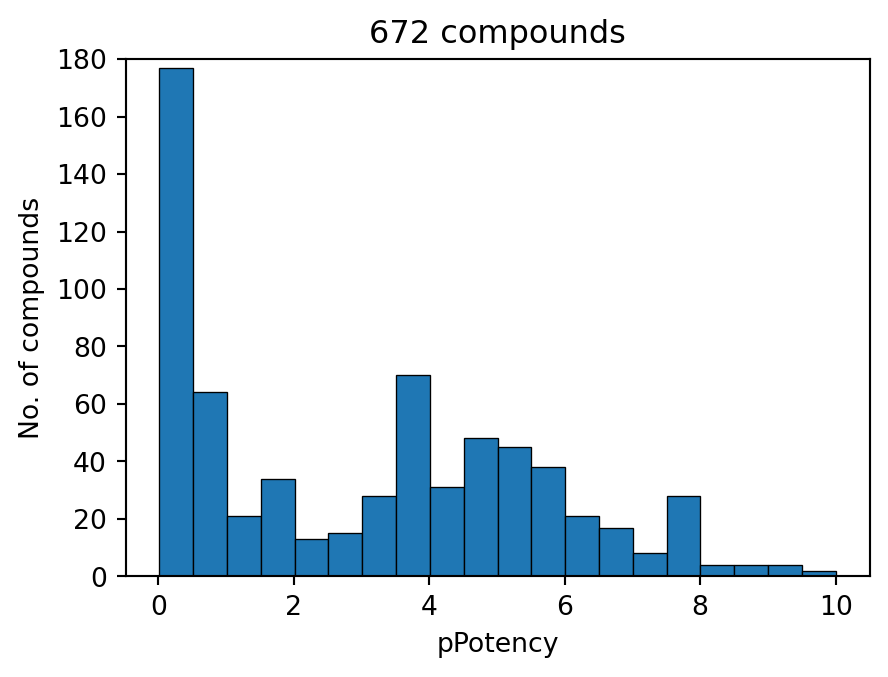

In [166]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [167]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [168]:
param_grid = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500], 
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding:

In [169]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=60, 
    n_landmarks=600, 
    random_state=42
)


After cleaning NaN values, reset the indices

In [170]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True) 


print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

Cleaned data has: 672 samples
Y index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### ML predictions with Train + Test results

In [171]:
%%time
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import Parallel, delayed
from copy import deepcopy

def process_fold(fold_id, train_index, test_index, smiles, Y, mcw, param_grid, num_partitions):
    """Process a single CV fold"""
    print(f"Partition {fold_id}/{num_partitions}")
    
    # Split data
    smi_train = smiles.iloc[train_index]
    smi_test = smiles.iloc[test_index]
    y_train = Y[train_index]
    y_test = Y[test_index]
    
    # Compute MACAW embeddings (clone to avoid conflicts)
    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)
    
    X_train = mcw_fold.transform(smi_train)
    X_test = mcw_fold.transform(smi_test)
    
    # Optimize hyperparameters
    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(X_train, y_train)
    
    best_params = grid.best_params_
    
    # Predict on both train and test
    y_cv_pred_train = grid.predict(X_train)
    y_cv_pred_test = grid.predict(X_test)
    
    # Calculate fold metrics
    train_mae = mean_absolute_error(y_train, y_cv_pred_train)
    test_mae = mean_absolute_error(y_test, y_cv_pred_test)
    print(f"  Fold {fold_id} - Train MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    
    # Return all predictions and parameters
    return {
        'train_pred': y_cv_pred_train,
        'train_obs': y_train,
        'test_pred': y_cv_pred_test,
        'test_obs': y_test,
        'best_params': best_params
    }

# Parallel execution
results = Parallel(n_jobs=4, verbose=10)(
    delayed(process_fold)(
        fold_id=i+1,
        train_index=train_idx,
        test_index=test_idx,
        smiles=smiles,
        Y=Y,
        mcw=mcw,
        param_grid=param_grid,
        num_partitions=num_of_partitions
    )
    for i, (train_idx, test_idx) in enumerate(kf.split(smiles))
)

# Combine results
Y_cv_pred_train = []
Y_obs_train = []
Y_cv_pred_test = []
Y_obs_test = []
best_params_per_fold = []

for fold_result in results:
    Y_cv_pred_train.extend(fold_result['train_pred'])
    Y_obs_train.extend(fold_result['train_obs'])
    Y_cv_pred_test.extend(fold_result['test_pred'])
    Y_obs_test.extend(fold_result['test_obs'])
    best_params_per_fold.append(fold_result['best_params'])

# Convert to numpy arrays
Y_cv_pred_train = np.array(Y_cv_pred_train)
Y_obs_train = np.array(Y_obs_train)
Y_cv_pred_test = np.array(Y_cv_pred_test)
Y_obs_test = np.array(Y_obs_test)

# ===== OVERALL METRICS =====
print("\n" + "-"*40)
print("Cross Validation Metrics")
print("-"*40)

# Train metrics
train_mae = mean_absolute_error(Y_obs_train, Y_cv_pred_train)
train_rmse = np.sqrt(mean_squared_error(Y_obs_train, Y_cv_pred_train))
train_r2 = r2_score(Y_obs_train, Y_cv_pred_train)

print(f"Train Set:")
print(f"  MAE:  {train_mae:.2f}")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  R²:   {train_r2:.2f}")

# Test metrics
test_mae = mean_absolute_error(Y_obs_test, Y_cv_pred_test)
test_rmse = np.sqrt(mean_squared_error(Y_obs_test, Y_cv_pred_test))
test_r2 = r2_score(Y_obs_test, Y_cv_pred_test)

print(f"Test Set:")
print(f"  MAE:  {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  R²:   {test_r2:.2f}")

print(f"\nBest params (sample): {best_params_per_fold[:3]}")


----------------------------------------
Cross Validation Metrics
----------------------------------------
Train Set:
  MAE:  1.18
  RMSE: 1.63
  R²:   0.59
Test Set:
  MAE:  1.42
  RMSE: 1.96
  R²:   0.42

Best params (sample): [{'C': 10, 'epsilon': 1, 'kernel': 'rbf'}, {'C': 7, 'epsilon': 1, 'kernel': 'rbf'}, {'C': 7, 'epsilon': 1, 'kernel': 'rbf'}]
CPU times: user 270 ms, sys: 133 ms, total: 403 ms
Wall time: 18 s


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW//BacillusAnthracis_CV_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW//BacillusAnthracis_CV_TrTs.png


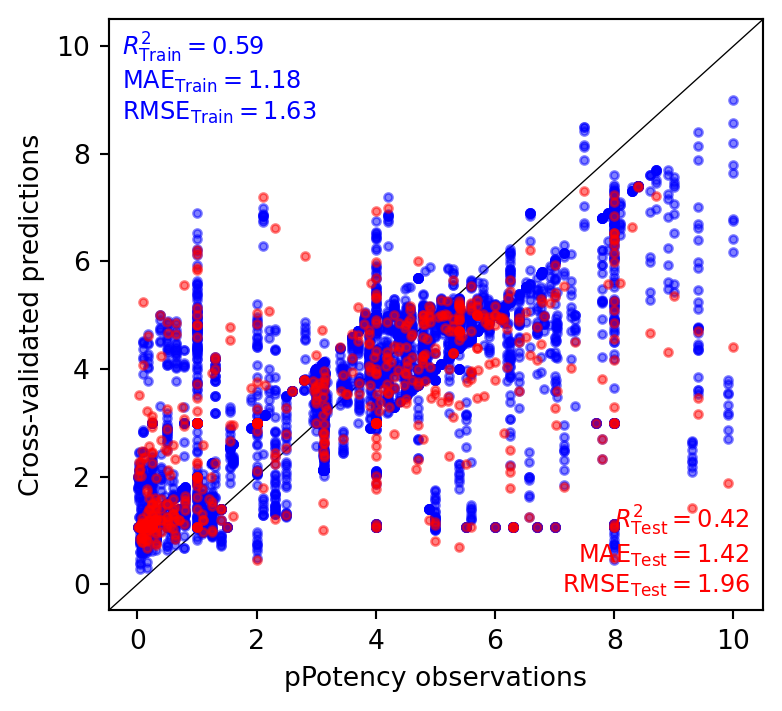

In [172]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=saveDir + '/BacillusAnthracis_CV_TrTs.svg',
            save_formats=['svg', 'png'])

Generate a model trained on the whole data set, to be used for prediction tasks

Training samples: 537
Test samples: 135
Feature dimensions: 100

Running GridSearchCV with 4 parallel jobs...

------------------------------------------------------------
Best Hyperparameters:
------------------------------------------------------------
  C: 10
  epsilon: 0.1
  kernel: rbf

Best CV MAE (on training folds): 1.18

------------------------------------------------------------
PERFORMANCE COMPARISON:
------------------------------------------------------------
Metric     Training        Test            Difference     
------------------------------------------------------------
R²         0.67            0.18            0.49           
MAE        0.65            1.35            0.70           
RMSE       1.47            2.30            0.83           
------------------------------------------------------------


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW//BacillusAnthracis_fullData_TrTs.svg
Saved: /mnt/dat

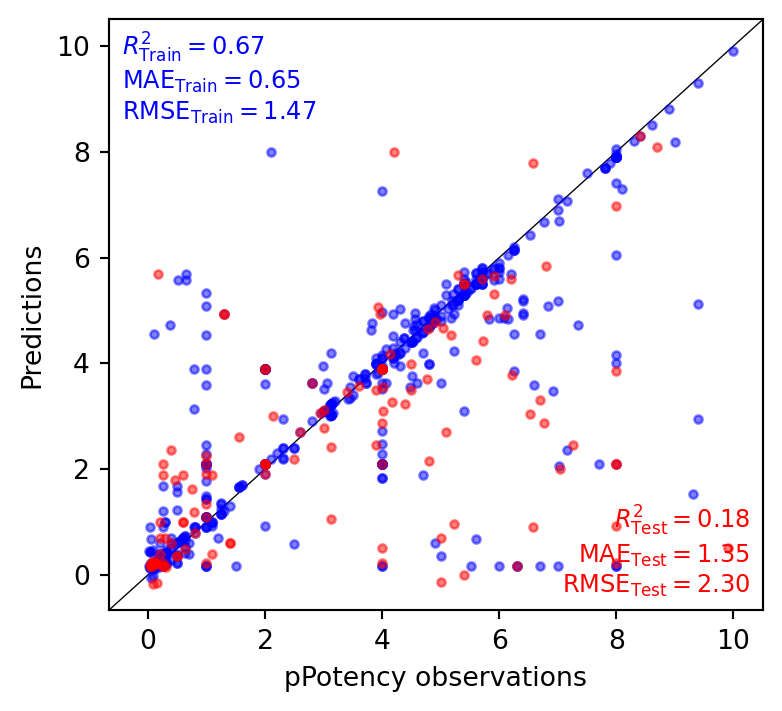

CPU times: user 1.96 s, sys: 121 ms, total: 2.08 s
Wall time: 3.34 s


In [173]:
%%time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# ---------------------------
# 1. TRAIN-TEST SPLIT
# ---------------------------
# Since you're working with only one virus group, use regular train_test_split
X_train_smi, X_test_smi, Y_train, Y_test = train_test_split(
    smiles, Y, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print(f"Training samples: {len(X_train_smi)}")
print(f"Test samples: {len(X_test_smi)}")

# ---------------------------
# 2. FIT MACAW ON TRAINING DATA ONLY
# ---------------------------
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=100, 
    n_landmarks=500, 
    random_state=42
)
mcw.fit(X_train_smi, Y_train)

# Transform both train and test
X_train = mcw.transform(X_train_smi)
X_test = mcw.transform(X_test_smi)

print(f"Feature dimensions: {X_train.shape[1]}")

# ---------------------------
# 3. GRID SEARCH ON TRAINING DATA ONLY
# ---------------------------
n_jobs = 4

regr_pred = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    refit=True,
    n_jobs=n_jobs,
    verbose=0,
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    pre_dispatch='2*n_jobs'
)

print(f"\nRunning GridSearchCV with {n_jobs} parallel jobs...")
regr_pred.fit(X_train, Y_train)

# ---------------------------
# 4. DISPLAY BEST HYPERPARAMETERS
# ---------------------------
print("\n" + "-"*60)
print("Best Hyperparameters:")
print("-"*60)
for param, value in regr_pred.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV MAE (on training folds): {-regr_pred.best_score_:.2f}")

# ---------------------------
# 5. PREDICTIONS AND METRICS
# ---------------------------
# Training predictions (in-sample)
y_train_pred = regr_pred.predict(X_train)

# Test predictions (held-out)
y_test_pred = regr_pred.predict(X_test)

# Calculate metrics for TRAIN
train_r2 = r2_score(Y_train, y_train_pred)
train_mae = mean_absolute_error(Y_train, y_train_pred)
train_rmse = np.sqrt(np.mean((Y_train - y_train_pred)**2))

# Calculate metrics for TEST
test_r2 = r2_score(Y_test, y_test_pred)
test_mae = mean_absolute_error(Y_test, y_test_pred)
test_rmse = np.sqrt(np.mean((Y_test - y_test_pred)**2))

# ---------------------------
# 6. DISPLAY RESULTS
# ---------------------------
print("\n" + "-"*60)
print("PERFORMANCE COMPARISON:")
print("-"*60)
print(f"{'Metric':<10} {'Training':<15} {'Test':<15} {'Difference':<15}")
print("-"*60)
print(f"{'R²':<10} {train_r2:<15.2f} {test_r2:<15.2f} {abs(train_r2-test_r2):<15.2f}")
print(f"{'MAE':<10} {train_mae:<15.2f} {test_mae:<15.2f} {abs(train_mae-test_mae):<15.2f}")
print(f"{'RMSE':<10} {train_rmse:<15.2f} {test_rmse:<15.2f} {abs(train_rmse-test_rmse):<15.2f}")
print("-"*60)

# Check for overfitting
overfit_gap = train_r2 - test_r2
if overfit_gap > 0.1:
    print("\n  WARNING: Possible overfitting detected (R² gap > 0.1)")
elif test_r2 >= 0.7:
    print("\n Good generalization performance!")

print("\n" + "="*60)


# ---------------------------
# 7. GENERATE PARITY PLOT
# ---------------------------
parity_plot(
    x=Y_train,                      # observed train
    y=y_train_pred,                 # predicted train (in-sample)
    x_test=Y_test,                  # observed test
    y_test=y_test_pred,             # predicted test (held-out)
    xlabel="pPotency observations",
    ylabel="Predictions",
    savetitle=saveDir + '/BacillusAnthracis_fullData_TrTs.svg',
    save_formats=['svg', 'png']
)

## 2.1 Discovery of new hits specific to all Bacteriaes (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

### Create a list of data frames of all buyable antibiotic

In [174]:
EnamineAntibioticData = pd.read_csv(dataDir + "Enamine/Enamine_Antibacterial_Library_plated_32000cmpds_20251019.csv",
                                    sep=",", comment=None, skipinitialspace=True, engine="python", encoding="utf-8",          
                                     skiprows=1, skip_blank_lines=True)
print(f"Original Enamine data shape: {EnamineAntibioticData.shape}")

smiles_train = BacillusAnthracisData_chEMBL.Smiles

# Function to canonicalize SMILES using RDKit
def canonicalize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            return Chem.MolToSmiles(mol, canonical=True)
        else:
            return None
    except:
        return None

# Canonicalize training SMILES and create a set for fast lookup
canonical_train = set()
for smi in smiles_train:
    canonical_smi = canonicalize_smiles(smi)
    if canonical_smi is not None:
        canonical_train.add(canonical_smi)

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to Enamine data
EnamineAntibioticData['Canonical_SMILES'] = EnamineAntibioticData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~EnamineAntibioticData['Canonical_SMILES'].isin(canonical_train)
EnamineAntibioticData_filtered = EnamineAntibioticData[mask].copy()

# Remove the helper column if you don't need it
EnamineAntibioticData = EnamineAntibioticData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered Enamine data shape for validation: {EnamineAntibioticData.shape}")
print(f"Removed {EnamineAntibioticData_filtered.shape[0] - EnamineAntibioticData.shape[0]} duplicate compounds from Enamine data set")

# Now use the filtered data
smi_lib_EnamineDataset = EnamineAntibioticData.SMILES
EnamineAntibioticData['source_DataBase'] = 'Enamine_Antibiotic'
needed_cols = ['SMILES', 'source_DataBase']
EnamineAntibioticData = EnamineAntibioticData[needed_cols]

print(f"Total compounds to screen: {len(smi_lib_EnamineDataset)}")
EnamineAntibioticData.head()

Original Enamine data shape: (32000, 11)
Number of unique SMILES in training set: 398
Filtered Enamine data shape for validation: (32000, 11)
Removed 0 duplicate compounds from Enamine data set
Total compounds to screen: 32000


,SMILES,source_DataBase
0,CC1=NN=C(COC(=O)C=2C=CC(=C(C2)[N+]([O-])=O)N3C...,Enamine_Antibiotic
1,CC1=NC2=NC(=NN2C(C)=C1C)SCCCOC(=O)NC(N)=O,Enamine_Antibiotic
2,CC=1C=CC(=CC1)S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC...,Enamine_Antibiotic
3,CC(C)N1C=NC(=C1)S(=O)(=O)NC=2C=CN(CC=3C=CC=CN3)N2,Enamine_Antibiotic
4,O=C(O)CC=1C=CC(=CC1)S(=O)(=O)NC=2C=CC(Cl)=CC2O,Enamine_Antibiotic


In [175]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "LifeChemicals/LC_Antibacterial_Focused_Library.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

LCAntibioticData = pd.DataFrame(records)

print(f"Original LifeChemicals data shape: {LCAntibioticData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to LifeChemicals data (reusing canonical_train from code-1)
LCAntibioticData['Canonical_SMILES'] = LCAntibioticData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~LCAntibioticData['Canonical_SMILES'].isin(canonical_train)
LCAntibioticData_filtered = LCAntibioticData[mask].copy()

# Remove the helper column if you don't need it
LCAntibioticData = LCAntibioticData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered LifeChemicals data shape for validation: {LCAntibioticData.shape}")
print(f"Removed {LCAntibioticData_filtered.shape[0] - LCAntibioticData.shape[0]} duplicate compounds from LifeChemicals data set")

# Now use the filtered data
smi_lib_LCAntibioticData = LCAntibioticData.SMILES
LCAntibioticData['source_DataBase'] = 'LifeChemicals_Antibiotic'
needed_cols = ['SMILES', 'source_DataBase']
LCAntibioticData = LCAntibioticData[needed_cols]

print(f"Total compounds to screen: {len(smi_lib_LCAntibioticData)}")
LCAntibioticData.head()

Original LifeChemicals data shape: (15538, 26)
Number of unique SMILES in training set: 398
Filtered LifeChemicals data shape for validation: (15532, 26)
Removed 0 duplicate compounds from LifeChemicals data set
Total compounds to screen: 15532


,SMILES,source_DataBase
0,COC1CCCN(c2cc(N(C)C)ncn2)C1,LifeChemicals_Antibiotic
1,OC1CCCN(c2ncnc3c2CCCC3)C1,LifeChemicals_Antibiotic
2,CC(C)N1CCN(c2ncc(F)cn2)CC1,LifeChemicals_Antibiotic
3,CC1CN(c2cc(N(C)C)ncn2)CC(C)O1,LifeChemicals_Antibiotic
4,CN(C)c1cc(N2CCCC(O)C2)ncn1,LifeChemicals_Antibiotic


In [176]:
supplier = Chem.SDMolSupplier(dataDir + "ChemDiv/ChemDiv_Antibacterial_gramm_negative_12510.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

ChemDivAntiBioticData = pd.DataFrame(records)

print(f"Original ChemDiv data shape: {ChemDivAntiBioticData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to ChemDiv data (reusing canonical_train from previous code)
ChemDivAntiBioticData['Canonical_SMILES'] = ChemDivAntiBioticData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~ChemDivAntiBioticData['Canonical_SMILES'].isin(canonical_train)
ChemDivAntiBioticData_filtered = ChemDivAntiBioticData[mask].copy()

# Remove the helper column if you don't need it
ChemDivAntiBioticData = ChemDivAntiBioticData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered ChemDiv data shape for validation: {ChemDivAntiBioticData.shape}")
print(f"Removed {ChemDivAntiBioticData_filtered.shape[0] - ChemDivAntiBioticData.shape[0]} duplicate compounds from ChemDiv data set")

# Now use the filtered data
smi_lib_ChemDivAntiBioticData = ChemDivAntiBioticData.SMILES
ChemDivAntiBioticData['source_DataBase'] = 'ChemDiv_Antibiotic'
needed_cols = ['SMILES', 'source_DataBase']
ChemDivAntiBioticData = ChemDivAntiBioticData[needed_cols]

print(f"Total compounds to screen: {len(smi_lib_ChemDivAntiBioticData)}")
ChemDivAntiBioticData

Original ChemDiv data shape: (12510, 16)
Number of unique SMILES in training set: 398
Filtered ChemDiv data shape for validation: (12507, 16)
Removed 0 duplicate compounds from ChemDiv data set
Total compounds to screen: 12507


,SMILES,source_DataBase
0,O=C(Oc1ccc(-c2ccccc2)cc1)c1ccc([N+](=O)[O-])cc1,ChemDiv_Antibiotic
1,COc1ccc(/C=N/NC(=O)c2ccn(C)n2)cc1,ChemDiv_Antibiotic
2,CC1(C)OC1COc1cc(=O)oc2cc3occc3cc12,ChemDiv_Antibiotic
3,O=C(Cc1ccccc1)c1ccc(-c2ccccc2)cc1,ChemDiv_Antibiotic
4,O=C(Nc1ccc(Oc2ccccc2)cc1)c1cccc(C(=O)Nc2ccc(Oc...,ChemDiv_Antibiotic
...,...,...
12505,Nc1nc(Nc2ccccc2F)nc2ccccc12,ChemDiv_Antibiotic
12506,CNc1nc(Nc2ccccc2F)nc2ccccc12,ChemDiv_Antibiotic
12507,Nc1nc(Nc2ccccc2Cl)nc2ccccc12,ChemDiv_Antibiotic
12508,CNc1nc(Nc2ccccc2Cl)nc2ccccc12,ChemDiv_Antibiotic


In [177]:
%%time

# Concatenate in chunks and free memory 
DF_list = [
    EnamineAntibioticData,
    LCAntibioticData,
    ChemDivAntiBioticData,
]

BacillusAnthracis_all_Buyable_Antibiotic = pd.concat(DF_list, ignore_index=True)

# Free memory from individual dataframes
del EnamineAntibioticData
del LCAntibioticData
del ChemDivAntiBioticData
gc.collect()

print(f"Total molecules before deduplication: {len(BacillusAnthracis_all_Buyable_Antibiotic)}")

# Batch canonicalize SMILES using vectorized approach
def canonicalize_smiles_batch(smiles_series, batch_size=50000):
    results = []
    for i in range(0, len(smiles_series), batch_size):
        batch = smiles_series.iloc[i:i + batch_size]
        canonical = []
        for smi in batch:
            try:
                mol = Chem.MolFromSmiles(smi)
                if mol is not None:
                    canonical.append(Chem.MolToSmiles(mol))
                else:
                    canonical.append(None)
            except:
                canonical.append(None)
        results.extend(canonical)
        print(f"  Processed {min(i + batch_size, len(smiles_series))}/{len(smiles_series)} SMILES...")
        gc.collect()
    return results

print("Canonicalizing SMILES...")
BacillusAnthracis_all_Buyable_Antibiotic['SMILES'] = canonicalize_smiles_batch(BacillusAnthracis_all_Buyable_Antibiotic['SMILES'])

# Drop invalid and duplicate SMILES
BacillusAnthracis_all_Buyable_Antibiotic = BacillusAnthracis_all_Buyable_Antibiotic.dropna(subset=['SMILES'])
BacillusAnthracis_all_Buyable_Antibiotic = BacillusAnthracis_all_Buyable_Antibiotic.drop_duplicates(subset='SMILES', keep='first')
BacillusAnthracis_all_Buyable_Antibiotic = BacillusAnthracis_all_Buyable_Antibiotic.reset_index(drop=True)
gc.collect()

print(f"Total molecules after deduplication: {len(BacillusAnthracis_all_Buyable_Antibiotic)}")

# Save to a file path string
output_path = saveDir + "BacillusAnthracis_all_Buyable_Antibiotic.csv"
BacillusAnthracis_all_Buyable_Antibiotic.to_csv(output_path, index=False, encoding="utf-8")
print(f"Saved to {output_path}")

BacillusAnthracis_all_Buyable_Antibiotic

Total molecules before deduplication: 60039
Canonicalizing SMILES...
  Processed 50000/60039 SMILES...
  Processed 60039/60039 SMILES...
Total molecules after deduplication: 59751
Saved to /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW/BacillusAnthracis_all_Buyable_Antibiotic.csv
CPU times: user 12.1 s, sys: 256 ms, total: 12.4 s
Wall time: 12.4 s


,SMILES,source_DataBase
0,Cc1nnc(COC(=O)c2ccc(N3CC(C)CC(C)C3)c([N+](=O)[...,Enamine_Antibiotic
1,Cc1nc2nc(SCCCOC(=O)NC(N)=O)nn2c(C)c1C,Enamine_Antibiotic
2,Cc1ccc(S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC(C)C2)cc1,Enamine_Antibiotic
3,CC(C)n1cnc(S(=O)(=O)Nc2ccn(Cc3ccccn3)n2)c1,Enamine_Antibiotic
4,O=C(O)Cc1ccc(S(=O)(=O)Nc2ccc(Cl)cc2O)cc1,Enamine_Antibiotic
...,...,...
59746,Nc1nc(Nc2ccccc2F)nc2ccccc12,ChemDiv_Antibiotic
59747,CNc1nc(Nc2ccccc2F)nc2ccccc12,ChemDiv_Antibiotic
59748,Nc1nc(Nc2ccccc2Cl)nc2ccccc12,ChemDiv_Antibiotic
59749,CNc1nc(Nc2ccccc2Cl)nc2ccccc12,ChemDiv_Antibiotic


### Generate `MACAW` embeedings for all buyable molecules --> to run external validation with `ART`

In [178]:
# ---------------------------
# 1. LOAD MACAW TRANSFORMER AND GENERATE EMBEDDINGS
# ---------------------------
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(modelBuildingDataDir, "BacillusAnthracisData_chEMBL_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(BacillusAnthracis_all_Buyable_Antibiotic['SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# ---------------------------
# 2. CREATE DATAFRAME WITH EMBEDDINGS
# ---------------------------
# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=BacillusAnthracis_all_Buyable_Antibiotic.index)

# ---------------------------
# 3. CONCATENATE WITH ORIGINAL DATAFRAME
# ---------------------------
BacillusAnthracis_all_Buyable_Antibiotic_wMACAW = pd.concat([BacillusAnthracis_all_Buyable_Antibiotic, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {BacillusAnthracis_all_Buyable_Antibiotic.shape}")
print(f"New dataframe shape: {BacillusAnthracis_all_Buyable_Antibiotic_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
BacillusAnthracis_all_Buyable_Antibiotic_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "BacillusAnthracis_all_Buyable_Antibiotic_wMACAW.csv"), index=False)
BacillusAnthracis_all_Buyable_Antibiotic_wMACAW.head()

MACAW transformer loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/BacillusAnthracisData_chEMBL_MACAW_transformer.joblib
50000
MACAW embeddings shape: (59751, 60)

Original dataframe shape: (59751, 2)
New dataframe shape: (59751, 62)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 'MACAW_58', 'MACAW_59'

,SMILES,source_DataBase,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
0,Cc1nnc(COC(=O)c2ccc(N3CC(C)CC(C)C3)c([N+](=O)[...,Enamine_Antibiotic,0.017822,-0.031148,0.020017,-0.020222,0.012164,0.077069,-0.063389,-0.011344,...,-0.037320,-0.021345,0.013182,0.015292,-0.047084,-0.014067,-0.027084,0.013258,0.013401,-0.020866
1,Cc1nc2nc(SCCCOC(=O)NC(N)=O)nn2c(C)c1C,Enamine_Antibiotic,0.032421,-0.031442,0.004046,0.048364,0.013279,0.046936,-0.015570,-0.044319,...,-0.015919,-0.032481,0.048531,0.011405,-0.024716,0.021793,0.011325,-0.019430,-0.004518,0.023860
2,Cc1ccc(S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC(C)C2)cc1,Enamine_Antibiotic,-0.002628,-0.036015,0.050915,-0.017189,0.039225,0.038531,-0.029022,0.013521,...,-0.008140,0.016043,-0.015800,-0.001052,-0.034377,-0.040059,-0.008138,-0.003538,-0.005770,0.010412
3,CC(C)n1cnc(S(=O)(=O)Nc2ccn(Cc3ccccn3)n2)c1,Enamine_Antibiotic,0.044011,0.025712,0.078685,0.032429,-0.055188,0.010798,-0.025298,0.005821,...,0.016592,-0.009813,0.009767,0.016698,-0.023944,-0.047351,-0.022834,-0.035694,0.015114,-0.018884
4,O=C(O)Cc1ccc(S(=O)(=O)Nc2ccc(Cl)cc2O)cc1,Enamine_Antibiotic,0.120759,-0.035132,0.042439,-0.006666,-0.039366,-0.095457,-0.009041,0.096862,...,0.012423,-0.011413,0.028651,0.001496,-0.015507,0.000842,-0.029758,-0.030924,-0.038550,0.002099


### Read results (`SMILES` & `Ppotency`) from `ART` post predictions with uncertentity

In [180]:
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction = pd.read_csv(ARTresultsDir + 'BacillusAnthracis_wART_EnamineDataset_predicted_all.csv')
max_val = BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction['pPotency_prediction'].max()
min_val = BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction

pPotency_prediction range: 0.883 → 6.329


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Cc1nnc(COC(=O)c2ccc(N3CC(C)CC(C)C3)c([N+](=O)[...,2.420812,1.929846,-1.361687,6.203311,0.003795,6.261649e-07,22.997815
1,Cc1nc2nc(SCCCOC(=O)NC(N)=O)nn2c(C)c1C,3.495472,1.932781,-0.292779,7.283722,0.000320,5.203287e-08,1.962362
2,Cc1ccc(S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC(C)C2)cc1,2.896828,1.930401,-0.886757,6.680413,0.001268,2.087308e-07,7.704731
3,CC(C)n1cnc(S(=O)(=O)Nc2ccn(Cc3ccccn3)n2)c1,3.727565,1.934292,-0.063648,7.518778,0.000187,3.028464e-08,1.157837
4,O=C(O)Cc1ccc(S(=O)(=O)Nc2ccc(Cl)cc2O)cc1,4.094989,1.938103,0.296307,7.893671,0.000080,1.277407e-08,0.505467
...,...,...,...,...,...,...,...,...
59746,Nc1nc(Nc2ccccc2F)nc2ccccc12,4.226625,1.954812,0.395194,8.058056,0.000059,8.748705e-09,0.402537
59747,CNc1nc(Nc2ccccc2F)nc2ccccc12,3.635805,1.958712,-0.203271,7.474882,0.000231,3.350567e-08,1.596876
59748,Nc1nc(Nc2ccccc2Cl)nc2ccccc12,4.236636,1.962426,0.390281,8.082991,0.000058,8.260558e-09,0.407117
59749,CNc1nc(Nc2ccccc2Cl)nc2ccccc12,3.757461,1.971891,-0.107446,7.622368,0.000175,2.385790e-08,1.280697


Partition 4/10
  Fold 4 - Train MAE: 1.19, Test MAE: 1.34
Partition 6/10
  Fold 6 - Train MAE: 1.23, Test MAE: 1.42
Partition 10/10
  Fold 10 - Train MAE: 1.22, Test MAE: 1.44
Partition 3/10
  Fold 3 - Train MAE: 1.20, Test MAE: 1.25
Partition 5/10
  Fold 5 - Train MAE: 1.18, Test MAE: 1.43
Partition 9/10
  Fold 9 - Train MAE: 1.13, Test MAE: 1.56
Partition 2/10
  Fold 2 - Train MAE: 1.21, Test MAE: 1.22
Partition 8/10
  Fold 8 - Train MAE: 1.15, Test MAE: 1.62
Partition 1/10
  Fold 1 - Train MAE: 1.12, Test MAE: 1.79
Partition 7/10
  Fold 7 - Train MAE: 1.20, Test MAE: 1.14


### Extract `pPotency` predictions

In [181]:
predicted_pPotency = BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction['pPotency_prediction'].values

### Filter out `top 20` compounds with higher `pPotency`

In [182]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]  # Last (20th) value
highest_pPotency = predicted_pPotency[top_20_idx[0]]   # First (1st) value

# Convert to IC50 in µM
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} (IC50: {cutoff_IC50_uM:.3f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} (IC50: {best_IC50_uM:.3f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} - {highest_pPotency:.2f}; IC50 --> {cutoff_IC50_uM:.3f} - {best_IC50_uM:.3f} µM")

Top 20 compounds cutoff pPotency: 5.50 (IC50: 3.1296 µM)
Highest predicted pPotency: 6.33 (IC50: 0.4687 µM)
pPotency range of top 20 compounds: pPotency --> 5.50 - 6.33; IC50 --> 3.130 - 0.4687 µM


In [183]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

# Create dataframe with top 20
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20 = BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)

# Add IC50 column in micromolar (µM)
# IC50 (µM) = 10^(-pPotency) * 1e6
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6

# Add rank column at the beginning
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = predicted_pPotency[top_20_idx[0]]   # Highest (best)
pPotency_min = predicted_pPotency[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min_uM = 10**(-pPotency_max) * 1e6            # Lowest IC50 (most potent)
IC50_max_uM = 10**(-pPotency_min) * 1e6            # Highest IC50 (least potent in top 20)

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max_uM:.3f} µM")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min_uM:.3f} µM")

print("\nRange for Top 20 Compounds:")
print(f"pPotency Range:   {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"IC50 Range (µM):  {IC50_max_uM:.3f} - {IC50_min_uM:.3f}")

# Set pandas display options
pd.options.display.float_format = lambda x: f'{x:.3f}'

# Display the dataframe
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20 = BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    5.505
  IC50:        3.1296 µM

Best Values (1st ranked compound):
  pPotency:    6.329
  IC50:        0.4687 µM

Range for Top 20 Compounds:
pPotency Range:   5.505 - 6.329
IC50 Range (µM):  3.1296 - 0.4687


,Rank,SMILES,pPotency_prediction,pPotency_std,IC50 (µM)
59624,1,Cc1cc2ncn(Cc3ccc(Cl)cc3Cl)c2cc1C,6.3290,1.9361,0.4687
41808,2,Cc1cc2ncn(Cc3ccc(Cl)cc3)c2cc1C,6.1090,1.9392,0.7774
42577,3,Nc1c(-c2ccc3ccccc3c2)nc2ccccn12,5.8460,1.9325,1.4257
53140,4,Cc1cccc(Cn2cnc3cc(C)c(C)cc32)c1,5.7560,1.9410,1.7534
41763,5,Cc1cc2ncn(Cc3ccccc3Cl)c2cc1C,5.7300,1.9353,1.8600
53139,6,Cc1ccc(Cn2cnc3cc(C)c(C)cc32)cc1,5.7260,1.9390,1.8772
42590,7,C=CCn1c(/C=C/c2ccccc2)nc2ccccc21,5.7220,1.9346,1.8955
44827,8,c1ccc(CCn2c(-c3ccccc3)nc3ccccc32)cc1,5.6880,1.9378,2.0491
37233,9,COc1ccc(Cn2cnc3ccccc32)cc1,5.6500,1.9386,2.2387
37739,10,Nc1cccc(-c2cn3ccccc3n2)c1,5.6500,1.9320,2.2401


In [184]:
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20.to_csv(os.path.join(saveDir + "BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20.csv"), index=False)
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20[['SMILES']].to_csv(os.path.join(saveDir + "BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20_SMILESonly.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW/BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20_Compounds.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW/BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20_Compounds.svg


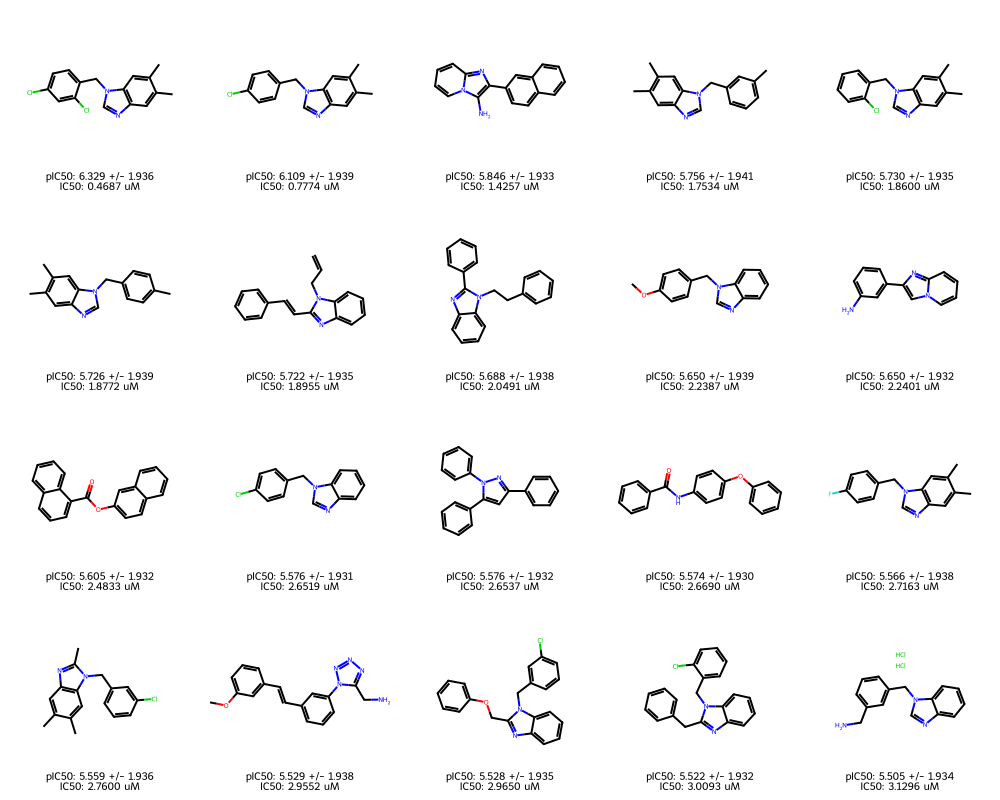

In [185]:
# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.3f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.3f} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)

### Save molecules as .gif

Saved GIF: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW/BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20_Compounds.gif


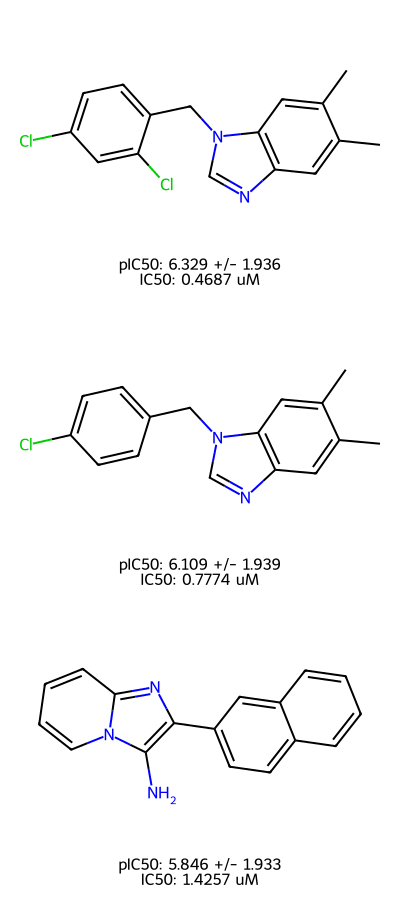

In [186]:
# Get molecules and legends
molecules = [Chem.MolFromSmiles(smi) for smi in BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.3f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.3f} uM"
    legends.append(legend)

# Split molecules into chunks of 4 for each frame
mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]
    
    # Generate grid image: 1 column (vertical layout), 4 rows
    frame_img = Draw.MolsToGridImage(
        chunk_mols,
        subImgSize=(400, 300),
        molsPerRow=1,  # 1 per row = vertical arrangement
        useSVG=False,
        legends=chunk_legends,
        returnPNG=False
    )
    
    # Convert to RGB if necessary (GIF requires consistent mode)
    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')
    
    frames.append(frame_img)

# Save as GIF
output_gif = saveDir + 'BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif,
    save_all=True,
    append_images=frames[1:],
    duration=3000,  # 3 seconds per frame
    loop=0,         # 0 = infinite loop
    optimize=True
)
print(f"Saved GIF: {output_gif}")

# Display in notebook
from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

### Add back `source_DataBase` column to keep track of the data base information for the compound

In [124]:
# Keep only the lookup columns (and drop duplicate SMILES to avoid row explosion)
lookupDF = (
    BacillusAnthracis_all_Buyable_Antibiotic[["SMILES", "source_DataBase"]]
    .dropna(subset=["SMILES"])
    .drop_duplicates(subset=["SMILES"], keep="first")
)

# Left-merge so every prediction row is preserved; source_DataBase is appended as the last column
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20 = BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20.merge(
    lookupDF,
    how="left",
    on="SMILES",
    validate="many_to_one"  # many predictions can map to one SMILES in lookup
)

BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20

,Rank,SMILES,pPotency_prediction,pPotency_std,IC50 (µM),source_DataBase
0,1,CCOC(=O)c1c(C)n(-c2ccc(C)cc2)c2ccc(OCC(O)CN3CC...,6.7780,0.6116,0.1667,LifeChemicals_Antivirals
1,2,CCC(=C(c1ccc(OC)cc1)c1ccc(OC)cc1)c1cn(CC(O)CN(...,6.7720,0.6095,0.1690,ChemDiv_Antivirals
2,3,CCOC(=O)c1c(C)n(-c2ccc(C)cc2)c2ccc(OCC(O)CN3CC...,6.7650,0.6131,0.1716,ChemDiv_Antivirals
3,4,CCOC(=O)c1c(C)n(-c2ccc(C)cc2)c2ccc(OCC(O)CN3CC...,6.7110,0.6132,0.1945,ChemDiv_Antivirals
4,5,CCN1CCCC1CNC(=O)c1ccc2c(c1)N(Cc1cc(C)ccc1C)C(=...,6.6870,0.6089,0.2057,ChemDiv_Antivirals
5,6,COc1ccc(C(O)(c2ccc(OC)cc2)c2ccc(CN(CCN3CCOCC3)...,6.6700,0.6075,0.2136,ChemDiv_Antivirals
6,7,CCN(C)CCN(CC)C(=O)CCc1cc2c(n1-c1ccc(C)cc1OC)-c...,6.6530,0.6084,0.2224,ChemDiv_Antivirals
7,8,CCOC(=O)c1c(C)n(-c2ccc(C)cc2)c2ccc(OCC(O)CN3CC...,6.6440,0.6117,0.2270,ChemDiv_Antivirals
8,9,CCOC(=O)c1c(C)n(-c2ccc(C)cc2)c2ccc(OCC(O)CN3CC...,6.6240,0.6125,0.2375,ChemDiv_Antivirals
9,10,CCN1CCN(S(=O)(=O)c2cc(NC(=O)C3CCCC3)ccc2Oc2c(C...,6.6080,0.6113,0.2467,ChemDiv_Antivirals


# <span style="color: #1e88e5;">Load <code>DORANET</code> generated molecules data</span>

### All `basidalin precursor` compounds generated by `DORAnet` --> Possible `Antibiotic`

In [213]:
basidalinPrecursor_DORAnetGenerated_Antibiotic = pd.read_csv(DORANETmoleculesDataDir + "basidalinPrecursor_DORAnetGeneratedMolecules.csv", dtype=str)
print(f"Loaded {len(basidalinPrecursor_DORAnetGenerated_Antibiotic)} molecules")
basidalinPrecursor_DORAnetGenerated_Antibiotic['source_DataBase'] = 'basidalin_Precursor'
basidalinPrecursor_DORAnetGenerated_Antibiotic

Loaded 651812 molecules


,SMILES,Is_Starter,SourceDirectories,source_DataBase
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor
...,...,...,...,...
651807,C[C@H](N)CC1=C(O)C(=O)OC1=C[C@@H](C)CNC=O,False,starter_02053,basidalin_Precursor
651808,Cc1c(O)c2oc1=C[C@@H](C)CNC(=O)[C@H](C)N=2,False,starter_02053,basidalin_Precursor
651809,C[C@H](C=C1OC(=O)C2=C1CO2)CNC(O)[C@H](C)N,False,starter_02053,basidalin_Precursor
651810,CC1=C2O[C@](C)(N)C(O)NC[C@H](C)C=C1OC2=O,False,starter_02053,basidalin_Precursor


### Generate `MACAW` embeedings for all `DORAnet` generated molecules --> to run external validation with `ART`

In [210]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(modelBuildingDataDir, "BacillusAnthracisData_chEMBL_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(basidalinPrecursor_DORAnetGenerated_Antibiotic['SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=basidalinPrecursor_DORAnetGenerated_Antibiotic.index)
basidalinPrecursor_DORAnetGenerated_Antibiotic_wMACAW = pd.concat([basidalinPrecursor_DORAnetGenerated_Antibiotic, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {basidalinPrecursor_DORAnetGenerated_Antibiotic.shape}")
print(f"New dataframe shape: {basidalinPrecursor_DORAnetGenerated_Antibiotic_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
basidalinPrecursor_DORAnetGenerated_Antibiotic_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "BacillusAnthracisData_basidalinPrecursor_DORAnetGenerated_Antibiotic_wMACAW.csv"), index=False)
basidalinPrecursor_DORAnetGenerated_Antibiotic_wMACAW.head()

MACAW transformer loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/BacillusAnthracisData_chEMBL_MACAW_transformer.joblib
50000
100000
150000
200000
250000
300000
350000
400000
450000
500000
550000
600000
650000
MACAW embeddings shape: (651812, 60)

Original dataframe shape: (651812, 4)
New dataframe shape: (651812, 64)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_

,SMILES,Is_Starter,SourceDirectories,source_DataBase,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor,-0.055,-0.040,0.039,0.016,-0.124,0.094,...,-0.017,0.011,0.026,0.023,-0.008,0.003,-0.010,-0.017,-0.023,0.015
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor,0.023,-0.092,0.068,0.050,-0.236,0.151,...,-0.017,0.023,0.013,0.007,0.010,-0.012,-0.017,0.001,0.010,-0.007
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor,-0.225,0.037,-0.038,-0.018,-0.044,-0.021,...,0.027,-0.025,0.010,0.033,0.009,-0.020,-0.008,0.009,-0.020,-0.001
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor,-0.231,0.037,-0.038,-0.022,-0.036,-0.027,...,0.027,-0.031,0.008,0.034,0.011,-0.017,-0.011,0.014,-0.025,0.002
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor,-0.013,-0.055,0.054,0.034,-0.172,0.127,...,-0.031,0.015,0.024,0.017,0.002,-0.001,-0.011,-0.004,-0.018,0.011


## Read results (`SMILES` & `Ppotency`) from `ART` post predictions with uncertentity

In [214]:
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction = pd.read_csv(ARTresultsDir + 'BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_ARTprediction.csv')
max_val = basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction['pPotency_prediction'].max()
min_val = basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction

pPotency_prediction range: 1.393 → 5.178


,SMILES,Is_Starter,SourceDirectories,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,basidalin_Precursor,3.527,1.930,-0.256,7.310,0.000,0.000,1.805
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,basidalin_Precursor,3.252,1.930,-0.531,7.035,0.001,0.000,3.392
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,basidalin_Precursor,2.690,1.934,-1.101,6.481,0.002,0.000,12.622
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,basidalin_Precursor,2.675,1.935,-1.118,6.468,0.002,0.000,13.135
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,basidalin_Precursor,3.274,1.932,-0.512,7.061,0.001,0.000,3.254
...,...,...,...,...,...,...,...,...,...,...
651806,C[C@H](N)CC1=C(O)C(=O)OC1=C[C@@H](C)CNC=O,False,basidalin_Precursor,2.638,1.934,-1.154,6.429,0.002,0.000,14.253
651807,Cc1c(O)c2oc1=C[C@@H](C)CNC(=O)[C@H](C)N=2,False,basidalin_Precursor,2.789,1.937,-1.007,6.585,0.002,0.000,10.152
651808,C[C@H](C=C1OC(=O)C2=C1CO2)CNC(O)[C@H](C)N,False,basidalin_Precursor,3.151,1.938,-0.647,6.949,0.001,0.000,4.438
651809,CC1=C2O[C@](C)(N)C(O)NC[C@H](C)C=C1OC2=O,False,basidalin_Precursor,3.136,1.941,-0.668,6.940,0.001,0.000,4.656


### Filter out `top 20` compounds with higher `pPotency` from all `DORAnet` generated molecules

In [215]:
predicted_pPotency = basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction['pPotency_prediction'].values
predicted_pPotency_std = basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction['pPotency_std'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]
highest_pPotency = predicted_pPotency[top_20_idx[0]]
cutoff_std = predicted_pPotency_std[top_20_idx[-1]]
highest_std = predicted_pPotency_std[top_20_idx[0]]
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} ± {cutoff_std:.2f} (IC50: {cutoff_IC50_uM:.4f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} ± {highest_std:.2f} (IC50: {best_IC50_uM:.4f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} ± {cutoff_std:.2f} - {highest_pPotency:.2f} ± {highest_std:.2f}; IC50 --> {cutoff_IC50_uM:.4f} - {best_IC50_uM:.4f} µM")

Top 20 compounds cutoff pPotency: 4.86 ± 1.96 (IC50: 13.9019 µM)
Highest predicted pPotency: 5.18 ± 1.93 (IC50: 6.6406 µM)
pPotency range of top 20 compounds: pPotency --> 4.86 ± 1.96 - 5.18 ± 1.93; IC50 --> 13.9019 - 6.6406 µM


In [216]:
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20 = basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction.iloc[top_20_idx].copy()
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

pd.options.display.float_format = lambda x: f'{x:.4f}'

basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20 = basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20

output_csv = os.path.join(saveDir, "basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.csv")
output_smiles_csv = os.path.join(saveDir, "basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20_SMILESonly.csv")
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.to_csv(output_csv, index=False)
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20[['SMILES']].to_csv(output_smiles_csv, index=False)
print(f" Saved results: {output_csv}")
print(f" Saved SMILES:  {output_smiles_csv}")

basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20

 Saved results: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW/basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.csv
 Saved SMILES:  /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW/basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20_SMILESonly.csv


,Rank,SMILES,pPotency_prediction,pPotency_std,IC50 (µM)
394271,1,Nc1ccc(Nc2ccc(O)cc2)cc1,5.1780,1.9310,6.6406
362220,2,O=C1C=CC(=CC=CC=C2C=CC(=O)O2)O1,5.1650,1.9361,6.8432
362209,3,O=C1C=CC(=CC=Cc2ccccc2)O1,5.1610,1.9363,6.9035
465858,4,O=C1C=CC(=Cc2ccc([N+](=O)[O-])cc2)O1,5.0850,1.9325,8.2312
464682,5,O=Cc1ccc(C=C2C=CC(=O)O2)cc1,5.0430,1.9354,9.0588
362498,6,O=C1OC(=CC=Cc2ccccc2)C=C1O,5.0050,1.9420,9.8815
464602,7,O=CC(=C1C=CC(=O)O1)c1ccccc1,4.9910,1.9358,10.2027
464657,8,O=Cc1cccc(C=C2C=CC(=O)O2)c1,4.9820,1.9387,10.4332
397466,9,Nc1ccc(C(C=O)=C2C=CC(=O)O2)cc1,4.9760,1.9343,10.5768
460848,10,O=C1C=CC(=CC(=O)c2ccccc2)O1,4.9660,1.9379,10.8204


### Display molecules

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW/basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20_Compounds.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW/basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20_Compounds.svg


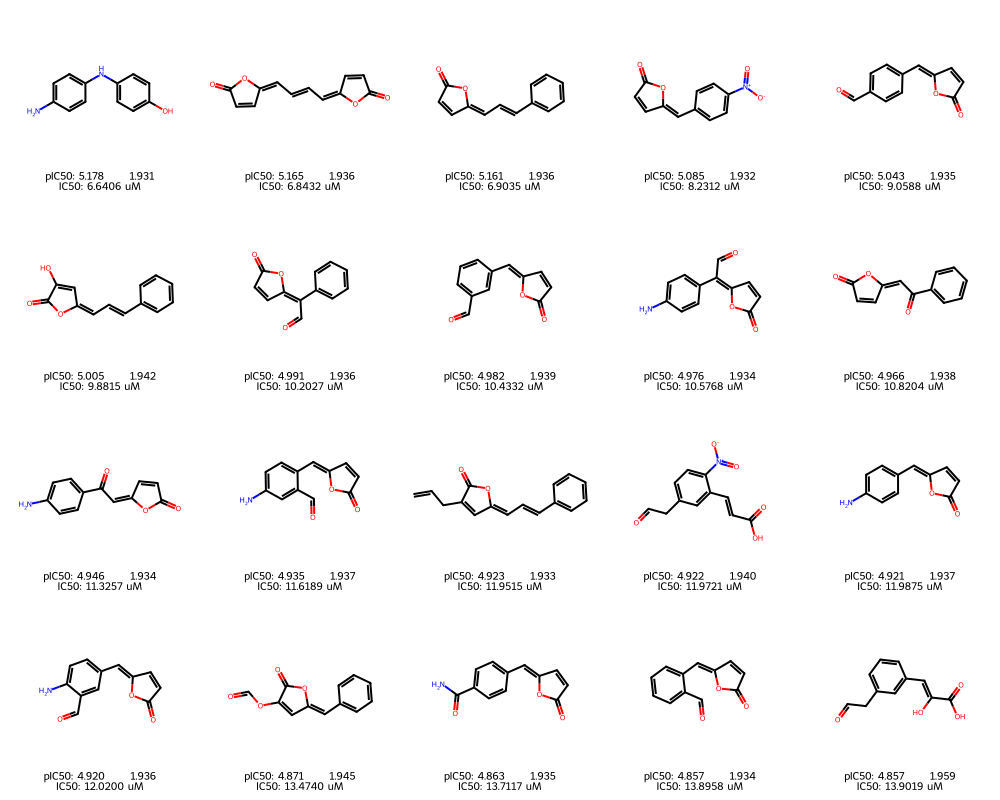

In [217]:
molecules = [Chem.MolFromSmiles(smi) for smi in basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} ± {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

img = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=False, legends=legends, returnPNG=False
)

output_png = saveDir + 'basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

svg = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=True, legends=legends
)

output_svg = saveDir + 'basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")

display(img)

### Display molecules in `.gif`

Saved GIF: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW/basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20_Compounds.gif


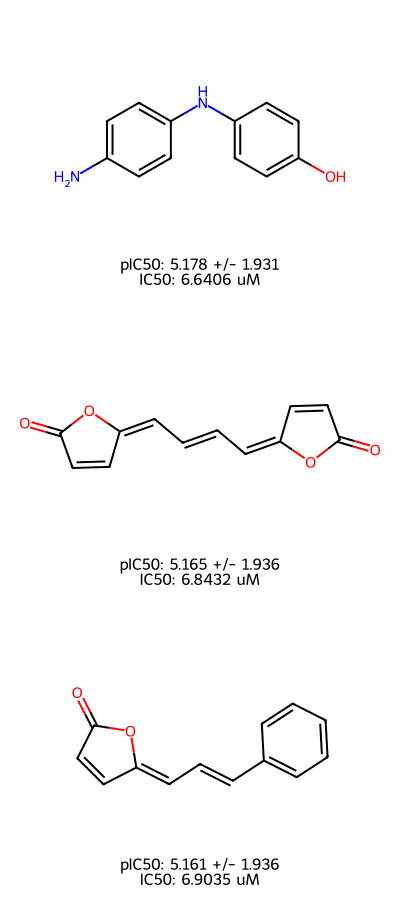

In [219]:
molecules = [Chem.MolFromSmiles(smi) for smi in basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]

    frame_img = Draw.MolsToGridImage(
        chunk_mols, subImgSize=(400, 300), molsPerRow=1,
        useSVG=False, legends=chunk_legends, returnPNG=False
    )

    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')

    frames.append(frame_img)

output_gif = saveDir + 'basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif, save_all=True, append_images=frames[1:],
    duration=3000, loop=2, optimize=True
)
print(f"Saved GIF: {output_gif}")

from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

### Checking drug likeliness of `Basidalin` only

In [29]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import pandas as pd

# SMILES strings
Basidalin_SMILES='C1=C(/C(=C\C=O)/OC1=O)N'

# Dictionary of drugs and their SMILES
drugs = {
    'Basidalin': Basidalin_SMILES,
}

# List to store results
smiles_data = []

# Process each drug
for drug_name, smiles in drugs.items():
    # Convert SMILES to molecule object
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is not None:
        smiles_data.append({
            'Drug_Name': drug_name,
            'SMILES': smiles,
            'Molecular_Formula': rdMolDescriptors.CalcMolFormula(mol),
            'Molecular_Weight': round(Descriptors.MolWt(mol), 2)
        })
        print(f" {drug_name}")
        print(f"  Formula: {rdMolDescriptors.CalcMolFormula(mol)}")
        print(f"  MW: {round(Descriptors.MolWt(mol), 2)} g/mol")
    else:
        print(f" Failed to parse SMILES for {drug_name}")

# Create DataFrame
DTRA_target_SMILES = pd.DataFrame(smiles_data)
smi_lib_DTRA_targets = DTRA_target_SMILES.SMILES
print(f"Total DTRA target compounds to screen: {len(smi_lib_DTRA_targets)}")
DTRA_target_SMILES

 Basidalin
  Formula: C6H5NO3
  MW: 139.11 g/mol
Total DTRA target compounds to screen: 1


,Drug_Name,SMILES,Molecular_Formula,Molecular_Weight
0,Basidalin,C1=C(/C(=C\C=O)/OC1=O)N,C6H5NO3,139.11


Generate predictions

In [30]:
smi_lib = smi_lib_DTRA_targets.copy()
smi_lib_DTRA_targets_wMACAW = mcw.transform(smi_lib_DTRA_targets)

# Create column names
num_features = smi_lib_DTRA_targets_wMACAW.shape[1]
column_names = [f'MACAW_{i+1}' for i in range(num_features)]

# Create DataFrame with same index as smi_lib
smi_lib_DTRA_targets = pd.DataFrame(smi_lib_DTRA_targets_wMACAW, columns=column_names, index=smi_lib.index)
# Then add SMILES as first column
smi_lib_DTRA_targets.insert(0, 'SMILES', smi_lib)
# Save to CSV
smi_lib_DTRA_targets.to_csv(os.path.join(saveDir + "BacillusAnthracis_DTRA_smiles_wMACAW.csv"), index=False)
smi_lib_DTRA_targets

,SMILES,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,MACAW_9,MACAW_10,MACAW_11,MACAW_12,MACAW_13,MACAW_14,MACAW_15
0,C1=C(/C(=C\C=O)/OC1=O)N,-0.080824,0.1082,-0.002592,-0.04377,-0.105452,0.024769,0.01638,-0.05921,0.038454,-0.055314,0.043648,0.04844,0.037117,-0.055977,-0.016365


# Now we will remove duplicate from training data and re-train the model

In [174]:
# Print shape before removing duplicates
print("Before removing duplicates:", BacillusAnthracisData_chEMBL.shape)

# Aggregate duplicates *within the same bacteria*
aggDF = (
    BacillusAnthracisData_chEMBL.groupby(['Smiles', 'BacteriaClassifier'], as_index=False)
      .agg({'pPotency': 'median'})   # or 'mean' if you prefer
)

# Merge back non-target columns (like MACAW features)
BacillusAnthracisData_chEMBL_noDuplicates = (aggDF
      .merge(
          aggDF.drop(columns=['pPotency']),
          on=['Smiles', 'BacteriaClassifier'],
          how='left'
      )
      .drop_duplicates(subset=['Smiles', 'BacteriaClassifier'])
      .reset_index(drop=True)
)

# Print shape after removing duplicates
print("After removing duplicates:", BacillusAnthracisData_chEMBL_noDuplicates.shape)

Before removing duplicates: (672, 5)
After removing duplicates: (398, 3)


In [175]:
duplicates = BacillusAnthracisData_chEMBL_noDuplicates.duplicated(subset=['Smiles'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 0


In [176]:
BacillusAnthracisData_chEMBL_noDuplicates.to_csv(os.path.join(modelBuildingDataDir, "BacillusAnthracisData_chEMBL_noDuplicates_MLready.csv"), index=False)

### Create MACAW embeedings to run ART

In [177]:
# ---------------------------
# 1. FIT MACAW AND GENERATE EMBEDDINGS
# ---------------------------
# Initialize MACAW
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=42
)


# Fit MACAW on SMILES and pPotency
mcw.fit(BacillusAnthracisData_chEMBL_noDuplicates['Smiles'], BacillusAnthracisData_chEMBL_noDuplicates['pPotency'])

# Save MACAW transformer
macaw_save_path = os.path.join(modelBuildingDataDir, "BacillusAnthracisData_chEMBL_noDuplicates_MACAW_transformer.joblib")
with open(macaw_save_path, 'wb') as f:
    pickle.dump(mcw, f)
print(f"MACAW transformer saved to: {macaw_save_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(BacillusAnthracisData_chEMBL_noDuplicates['Smiles'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# ---------------------------
# 2. CREATE DATAFRAME WITH EMBEDDINGS
# ---------------------------
# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=BacillusAnthracisData_chEMBL_noDuplicates.index)

# ---------------------------
# 3. CONCATENATE WITH ORIGINAL DATAFRAME
# ---------------------------
BacillusAnthracisData_chEMBL_noDuplicates_wMACAW = pd.concat([BacillusAnthracisData_chEMBL_noDuplicates, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {BacillusAnthracisData_chEMBL_noDuplicates.shape}")
print(f"New dataframe shape: {BacillusAnthracisData_chEMBL_noDuplicates_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
BacillusAnthracisData_chEMBL_noDuplicates_wMACAW

MACAW transformer saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/BacillusAnthracisData_chEMBL_noDuplicates_MACAW_transformer.joblib
MACAW embeddings shape: (398, 15)

Original dataframe shape: (398, 3)
New dataframe shape: (398, 18)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15']


,Smiles,BacteriaClassifier,pPotency,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,MACAW_9,MACAW_10,MACAW_11,MACAW_12,MACAW_13,MACAW_14,MACAW_15
0,Bc1ccc(SC(CC(=O)c2ccc(O)c(C)c2)c2ccc(Cl)cc2)cc1,Bacillus_anthracis,3.125000,-0.114680,-0.018396,-0.026362,0.080567,-0.093833,0.006934,0.021402,0.031633,0.008589,0.014145,0.046700,0.006196,0.003139,-0.017133,-0.034187
1,Brc1c(-c2ccc(-c3[nH]c4cc(C5=NCCN5)ccc4c3Br)cc2...,Bacillus_anthracis,0.080000,-0.036834,0.239892,0.157128,-0.269631,0.037234,-0.071563,0.081334,-0.025232,0.085741,-0.016091,0.029413,-0.139572,0.032962,-0.038663,0.034575
2,C(/C=C/c1cc2cc(C3=NCCN3)ccc2o1)=C\c1cc2cc(C3=N...,Bacillus_anthracis,9.900000,-0.077171,0.244661,0.128478,-0.208512,0.009074,-0.031277,-0.006497,-0.009444,0.107179,-0.037601,0.053382,-0.047900,0.005586,-0.017084,0.035262
3,C(=C/Cc1cc2ccc(C3=NCCCN3)cc2[nH]1)\Cc1cc2ccc(C...,Bacillus_anthracis,0.160000,-0.043097,0.262093,0.122823,-0.280451,0.030464,-0.059785,0.068512,-0.049018,0.058661,-0.047500,0.008684,-0.066172,0.025175,-0.030639,0.024684
4,C(=C/Cc1cc2ccc(C3=NCCN3)cc2[nH]1)\Cc1cc2ccc(C3...,Bacillus_anthracis,0.310000,-0.067400,0.269922,0.142092,-0.271582,0.038666,-0.058164,0.071516,-0.026362,0.070482,-0.032123,0.017145,-0.076793,0.018206,-0.040288,0.031678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393,c1cc2cc(-c3ccc4cc(-c5ccc6oc(C7=NCCN7)cc6c5)[nH...,Bacillus_anthracis,0.700000,-0.040402,0.254716,0.094331,-0.179593,0.025745,-0.028616,0.025978,0.011257,0.078930,-0.005201,0.053933,-0.018104,-0.032888,0.005820,0.013226
394,c1cc2cc(-c3ccc4cc(C5=NCCN5)[nH]c4c3)[nH]c2cc1C...,Bacillus_anthracis,0.600000,-0.121881,0.192960,0.114280,-0.154645,0.016269,-0.011606,0.058776,0.038733,-0.008025,0.023775,-0.021477,0.068369,-0.018013,0.015697,-0.012497
395,c1cc2cc(CCCCc3cc4ccc(C5=NCCCN5)cc4[nH]3)[nH]c2...,Bacillus_anthracis,1.250000,-0.041111,0.210966,0.106015,-0.253949,0.040616,-0.052883,0.066965,-0.043145,0.039208,-0.054789,-0.020277,-0.030530,0.021622,-0.031292,0.004964
396,c1cc2oc(-c3ccc(-c4cc5ccc(C6=NCCCN6)cc5[nH]4)cc...,Bacillus_anthracis,0.080000,-0.052672,0.298607,0.134982,-0.297031,0.025225,-0.056861,0.059454,-0.057850,0.090378,-0.048595,0.050759,-0.082928,0.030365,-0.048640,0.031482


In [178]:
BacillusAnthracisData_chEMBL_noDuplicates_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "BacillusAnthracisData_chEMBL_noDuplicates_wMACAW.csv"), index=False)

### Clip first 1000 rows from the data set for fast testing

### Train ML Model

In [207]:
# df = BacillusAnthracisData_chEMBL
Y = BacillusAnthracisData_chEMBL_noDuplicates.pPotency
smiles = BacillusAnthracisData_chEMBL_noDuplicates.Smiles

In [208]:
print(len(smiles))

398


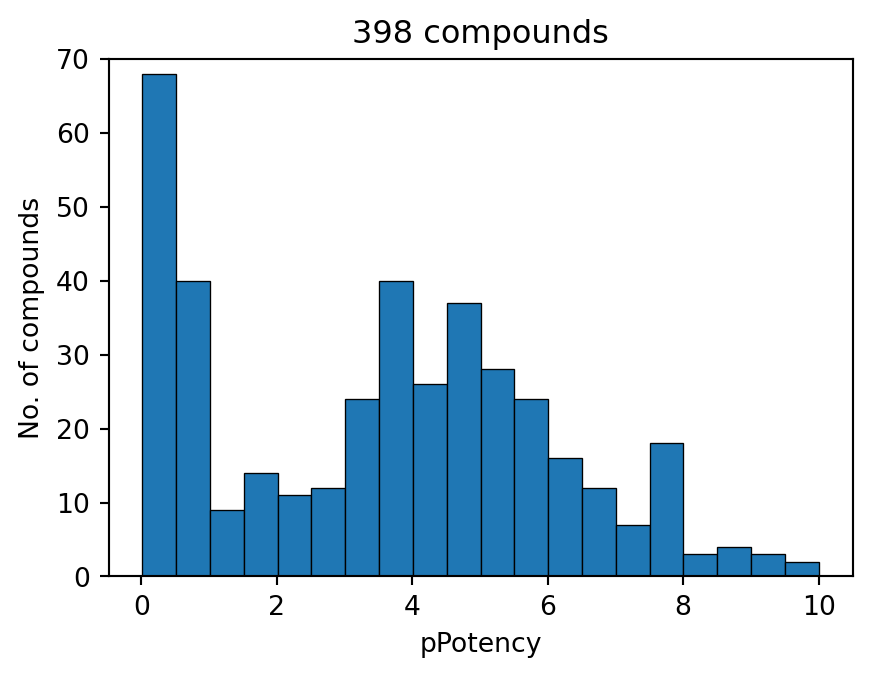

In [209]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [210]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [211]:
param_grid = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500], 
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding:

In [212]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=45, 
    n_landmarks=300, 
    random_state=39
)


After cleaning NaN values, reset the indices

In [213]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True) 


print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

Cleaned data has: 398 samples
Y index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### Create directory to save plot

In [214]:
save_path = saveDir + '/BacillusAnthracis_CV_testOnly.svg'
os.makedirs(os.path.dirname(save_path), exist_ok=True)

### ML predictions with Train + Test results

In [215]:
%%time
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import Parallel, delayed
from copy import deepcopy

def process_fold(fold_id, train_index, test_index, smiles, Y, mcw, param_grid, num_partitions):
    """Process a single CV fold"""
    print(f"Partition {fold_id}/{num_partitions}")
    
    # Split data
    smi_train = smiles.iloc[train_index]
    smi_test = smiles.iloc[test_index]
    y_train = Y[train_index]
    y_test = Y[test_index]
    
    # Compute MACAW embeddings (clone to avoid conflicts)
    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)
    
    X_train = mcw_fold.transform(smi_train)
    X_test = mcw_fold.transform(smi_test)
    
    # Optimize hyperparameters
    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(X_train, y_train)
    
    best_params = grid.best_params_
    
    # Predict on both train and test
    y_cv_pred_train = grid.predict(X_train)
    y_cv_pred_test = grid.predict(X_test)
    
    # Calculate fold metrics
    train_mae = mean_absolute_error(y_train, y_cv_pred_train)
    test_mae = mean_absolute_error(y_test, y_cv_pred_test)
    print(f"  Fold {fold_id} - Train MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    
    # Return all predictions and parameters
    return {
        'train_pred': y_cv_pred_train,
        'train_obs': y_train,
        'test_pred': y_cv_pred_test,
        'test_obs': y_test,
        'best_params': best_params
    }

# Parallel execution
results = Parallel(n_jobs=4, verbose=10)(
    delayed(process_fold)(
        fold_id=i+1,
        train_index=train_idx,
        test_index=test_idx,
        smiles=smiles,
        Y=Y,
        mcw=mcw,
        param_grid=param_grid,
        num_partitions=num_of_partitions
    )
    for i, (train_idx, test_idx) in enumerate(kf.split(smiles))
)

# Combine results
Y_cv_pred_train = []
Y_obs_train = []
Y_cv_pred_test = []
Y_obs_test = []
best_params_per_fold = []

for fold_result in results:
    Y_cv_pred_train.extend(fold_result['train_pred'])
    Y_obs_train.extend(fold_result['train_obs'])
    Y_cv_pred_test.extend(fold_result['test_pred'])
    Y_obs_test.extend(fold_result['test_obs'])
    best_params_per_fold.append(fold_result['best_params'])

# Convert to numpy arrays
Y_cv_pred_train = np.array(Y_cv_pred_train)
Y_obs_train = np.array(Y_obs_train)
Y_cv_pred_test = np.array(Y_cv_pred_test)
Y_obs_test = np.array(Y_obs_test)

# ===== OVERALL METRICS =====
print("\n" + "-"*40)
print("Cross Validation Metrics")
print("-"*40)

# Train metrics
train_mae = mean_absolute_error(Y_obs_train, Y_cv_pred_train)
train_rmse = np.sqrt(mean_squared_error(Y_obs_train, Y_cv_pred_train))
train_r2 = r2_score(Y_obs_train, Y_cv_pred_train)

print(f"Train Set:")
print(f"  MAE:  {train_mae:.2f}")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  R²:   {train_r2:.2f}")

# Test metrics
test_mae = mean_absolute_error(Y_obs_test, Y_cv_pred_test)
test_rmse = np.sqrt(mean_squared_error(Y_obs_test, Y_cv_pred_test))
test_r2 = r2_score(Y_obs_test, Y_cv_pred_test)

print(f"Test Set:")
print(f"  MAE:  {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  R²:   {test_r2:.2f}")

print(f"\nBest params (sample): {best_params_per_fold[:3]}")


----------------------------------------
Cross Validation Metrics
----------------------------------------
Train Set:
  MAE:  1.49
  RMSE: 1.90
  R²:   0.42
Test Set:
  MAE:  1.70
  RMSE: 2.18
  R²:   0.24

Best params (sample): [{'C': 1, 'epsilon': 1, 'kernel': 'rbf'}, {'C': 1, 'epsilon': 1, 'kernel': 'rbf'}, {'C': 7, 'epsilon': 3, 'kernel': 'rbf'}]
CPU times: user 195 ms, sys: 68 ms, total: 263 ms
Wall time: 5.72 s


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis/BacillusAnthracis_noDuplicates_noDuplicates_CV_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis/BacillusAnthracis_noDuplicates_noDuplicates_CV_TrTs.png


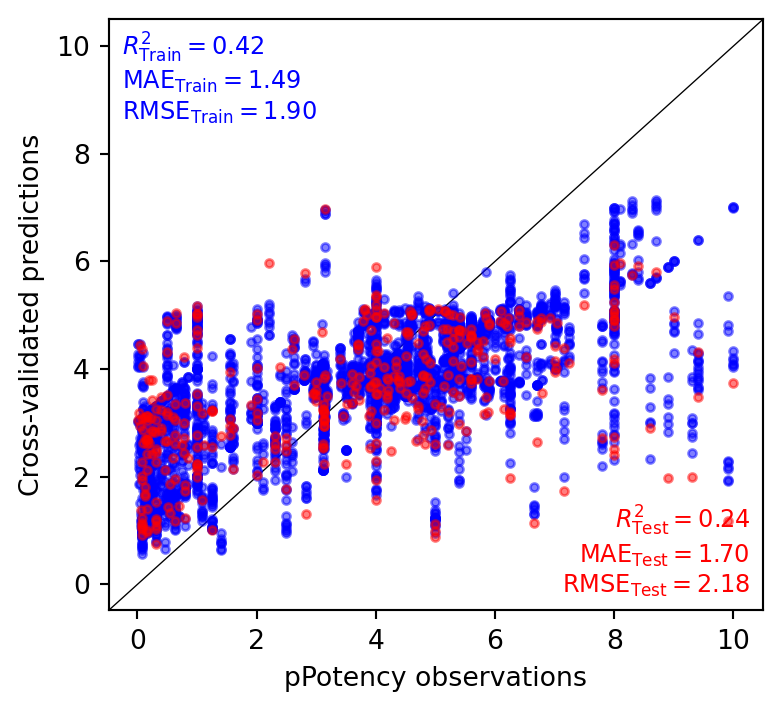

In [216]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=saveDir + '/BacillusAnthracis_noDuplicates_noDuplicates_CV_TrTs.svg',
            save_formats=['svg', 'png'])

Generate a model trained on the whole data set, to be used for prediction tasks

Training samples: 318
Test samples: 80
Feature dimensions: 45

Running GridSearchCV with 4 parallel jobs...

------------------------------------------------------------
Best Hyperparameters:
------------------------------------------------------------
  C: 10
  epsilon: 0.1
  kernel: rbf

Best CV MAE (on training folds): 1.37

------------------------------------------------------------
PERFORMANCE COMPARISON:
------------------------------------------------------------
Metric     Training        Test            Difference     
------------------------------------------------------------
R²         0.71            0.36            0.36           
MAE        0.65            1.37            0.72           
RMSE       1.33            2.01            0.68           
------------------------------------------------------------


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis/BacillusAnthracis_noDuplicates_fullData_TrTs.svg
Saved: /mnt/data

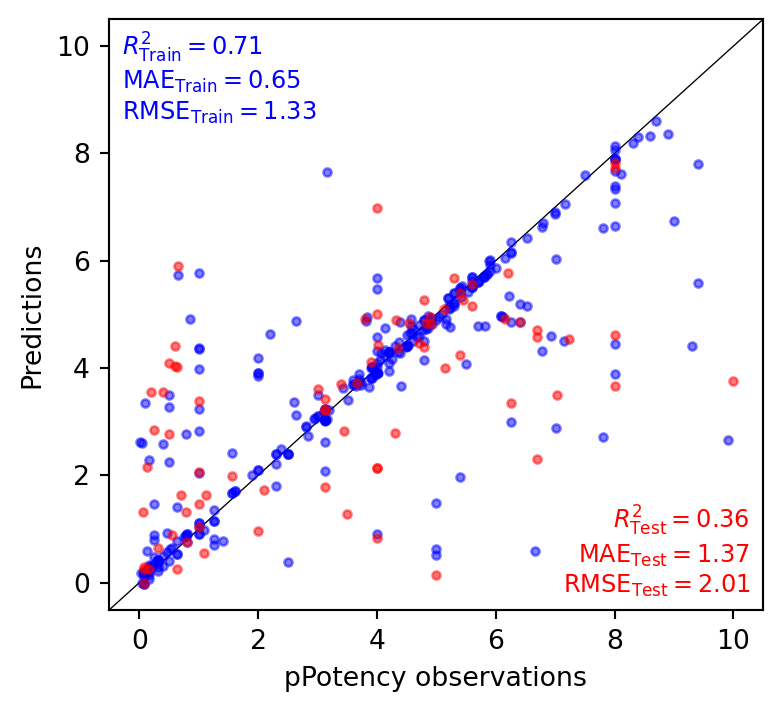

CPU times: user 1.28 s, sys: 44.4 ms, total: 1.32 s
Wall time: 1.59 s


In [217]:
%%time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# ---------------------------
# 1. TRAIN-TEST SPLIT
# ---------------------------
# Since you're working with only one virus group, use regular train_test_split
X_train_smi, X_test_smi, Y_train, Y_test = train_test_split(
    smiles, Y, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print(f"Training samples: {len(X_train_smi)}")
print(f"Test samples: {len(X_test_smi)}")

# ---------------------------
# 2. FIT MACAW ON TRAINING DATA ONLY
# ---------------------------
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=45, 
    n_landmarks=300, 
    random_state=42
)
mcw.fit(X_train_smi, Y_train)

# Transform both train and test
X_train = mcw.transform(X_train_smi)
X_test = mcw.transform(X_test_smi)

print(f"Feature dimensions: {X_train.shape[1]}")

# ---------------------------
# 3. GRID SEARCH ON TRAINING DATA ONLY
# ---------------------------
n_jobs = 4

regr_pred = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    refit=True,
    n_jobs=n_jobs,
    verbose=0,
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    pre_dispatch='2*n_jobs'
)

print(f"\nRunning GridSearchCV with {n_jobs} parallel jobs...")
regr_pred.fit(X_train, Y_train)

# ---------------------------
# 4. DISPLAY BEST HYPERPARAMETERS
# ---------------------------
print("\n" + "-"*60)
print("Best Hyperparameters:")
print("-"*60)
for param, value in regr_pred.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV MAE (on training folds): {-regr_pred.best_score_:.2f}")

# ---------------------------
# 5. PREDICTIONS AND METRICS
# ---------------------------
# Training predictions (in-sample)
y_train_pred = regr_pred.predict(X_train)

# Test predictions (held-out)
y_test_pred = regr_pred.predict(X_test)

# Calculate metrics for TRAIN
train_r2 = r2_score(Y_train, y_train_pred)
train_mae = mean_absolute_error(Y_train, y_train_pred)
train_rmse = np.sqrt(np.mean((Y_train - y_train_pred)**2))

# Calculate metrics for TEST
test_r2 = r2_score(Y_test, y_test_pred)
test_mae = mean_absolute_error(Y_test, y_test_pred)
test_rmse = np.sqrt(np.mean((Y_test - y_test_pred)**2))

# ---------------------------
# 6. DISPLAY RESULTS
# ---------------------------
print("\n" + "-"*60)
print("PERFORMANCE COMPARISON:")
print("-"*60)
print(f"{'Metric':<10} {'Training':<15} {'Test':<15} {'Difference':<15}")
print("-"*60)
print(f"{'R²':<10} {train_r2:<15.2f} {test_r2:<15.2f} {abs(train_r2-test_r2):<15.2f}")
print(f"{'MAE':<10} {train_mae:<15.2f} {test_mae:<15.2f} {abs(train_mae-test_mae):<15.2f}")
print(f"{'RMSE':<10} {train_rmse:<15.2f} {test_rmse:<15.2f} {abs(train_rmse-test_rmse):<15.2f}")
print("-"*60)

# Check for overfitting
overfit_gap = train_r2 - test_r2
if overfit_gap > 0.1:
    print("\n  WARNING: Possible overfitting detected (R² gap > 0.1)")
elif test_r2 >= 0.7:
    print("\n Good generalization performance!")

print("\n" + "="*60)


# ---------------------------
# 7. GENERATE PARITY PLOT
# ---------------------------
parity_plot(
    x=Y_train,                      # observed train
    y=y_train_pred,                 # predicted train (in-sample)
    x_test=Y_test,                  # observed test
    y_test=y_test_pred,             # predicted test (held-out)
    xlabel="pPotency observations",
    ylabel="Predictions",
    savetitle=saveDir + '/BacillusAnthracis_noDuplicates_fullData_TrTs.svg',
    save_formats=['svg', 'png']
)

## 2.1 Discovery of new hits specific to all Bacteriaes (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [218]:
EnamineAntibioticData = pd.read_csv(dataDir + "Enamine/Enamine_Antibacterial_Library_plated_32000cmpds_20251019.csv",
                                    sep=",", comment=None, skipinitialspace=True, engine="python", encoding="utf-8",          
                                     skiprows=1, skip_blank_lines=True)
print(f"Original Enamine data shape: {EnamineAntibioticData.shape}")

smiles_train = BacillusAnthracisData_chEMBL_noDuplicates.Smiles

# Function to canonicalize SMILES using RDKit
def canonicalize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            return Chem.MolToSmiles(mol, canonical=True)
        else:
            return None
    except:
        return None

# Canonicalize training SMILES and create a set for fast lookup
canonical_train = set()
for smi in smiles_train:
    canonical_smi = canonicalize_smiles(smi)
    if canonical_smi is not None:
        canonical_train.add(canonical_smi)

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to Enamine data
EnamineAntibioticData['Canonical_SMILES'] = EnamineAntibioticData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~EnamineAntibioticData['Canonical_SMILES'].isin(canonical_train)
EnamineAntibioticData_filtered = EnamineAntibioticData[mask].copy()

# Remove the helper column if you don't need it
EnamineAntibioticData = EnamineAntibioticData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered Enamine data shape for validation: {EnamineAntibioticData.shape}")
print(f"Removed {EnamineAntibioticData.shape[0] - EnamineAntibioticData_filtered.shape[0]} duplicate compounds from Enamine data set")

# Now use the filtered data
smi_lib = EnamineAntibioticData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
EnamineAntibioticData.head()

Original Enamine data shape: (32000, 11)
Number of unique SMILES in training set: 398
Filtered Enamine data shape for validation: (32000, 11)
Removed 0 duplicate compounds from Enamine data set
Total compounds to screen: 32000


,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL
0,CC1=NN=C(COC(=O)C=2C=CC(=C(C2)[N+]([O-])=O)N3C...,Z19065527,374.392,374.392,2.754,-4.286,0,6,111.600,6,https://real.enamine.net/public-enum-files/Z19...
1,CC1=NC2=NC(=NN2C(C)=C1C)SCCCOC(=O)NC(N)=O,Z1203040657,338.387,338.387,1.246,-4.006,2,5,124.500,8,https://real.enamine.net/public-enum-files/Z12...
2,CC=1C=CC(=CC1)S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC...,Z19154552,384.449,384.449,2.021,-3.375,1,5,102.010,6,https://real.enamine.net/public-enum-files/Z19...
3,CC(C)N1C=NC(=C1)S(=O)(=O)NC=2C=CN(CC=3C=CC=CN3)N2,Z1509821346,346.409,346.409,1.094,-1.970,1,5,94.700,6,https://real.enamine.net/public-enum-files/Z15...
4,O=C(O)CC=1C=CC(=CC1)S(=O)(=O)NC=2C=CC(Cl)=CC2O,Z1509833014,341.768,341.768,2.254,-3.235,3,5,103.700,4,https://real.enamine.net/public-enum-files/Z15...


Load pre-trained models for very large data sets or

Generate MACAW embeddings

In [219]:
print("\nComputing MACAW embeddings")
X1_lib = mcw.transform(smi_lib)
print(f"Embedding shape: {X1_lib.shape}")


Computing MACAW embeddings
Embedding shape: (32000, 45)


Predict pPotency

In [220]:
print("Generating predictions")
Y1_lib_pred = regr_pred.predict(X1_lib)
print(f"Predictions shape: {Y1_lib_pred.shape}")

Generating predictions
Predictions shape: (32000,)


Add predictions to dataframe

In [221]:
EnamineAntibioticData_predicted = EnamineAntibioticData.copy()
EnamineAntibioticData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
EnamineAntibioticData_predicted['IC50 (M)'] = 10 ** (-EnamineAntibioticData_predicted['pPotency_prediction'])

EnamineAntibioticData_predicted = EnamineAntibioticData_predicted.filter(
    items=["SMILES", "pPotency_prediction", "IC50 (M)"]
)
EnamineAntibioticData_predicted.to_csv(os.path.join(resultsDir + "BacillusAnthracis/BacillusAnthracis_noDuplicates_EnamineDatasets_predicted_all.csv"), index=False)
EnamineAntibioticData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "BacillusAnthracis/BacillusAnthracis_noDuplicates_EnamineDatasets_predicted_all_SMILES.csv"), index=False)
EnamineAntibioticData_predicted

,SMILES,pPotency_prediction,IC50 (M)
0,CC1=NN=C(COC(=O)C=2C=CC(=C(C2)[N+]([O-])=O)N3C...,2.291,5.123e-03
1,CC1=NC2=NC(=NN2C(C)=C1C)SCCCOC(=O)NC(N)=O,3.608,2.466e-04
2,CC=1C=CC(=CC1)S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC...,2.001,9.977e-03
3,CC(C)N1C=NC(=C1)S(=O)(=O)NC=2C=CN(CC=3C=CC=CN3)N2,3.565,2.726e-04
4,O=C(O)CC=1C=CC(=CC1)S(=O)(=O)NC=2C=CC(Cl)=CC2O,3.788,1.631e-04
...,...,...,...
31995,CCOCCCOC(=O)C1=CC(=C(C)S1)[N+]([O-])=O,2.277,5.289e-03
31996,CC(C)C(NS(=O)(=O)CC12CCC(CC1=O)C2(C)C)C(N)=O,2.296,5.061e-03
31997,CNC(=O)CN1CCC(CC1)NS(=O)(=O)CCCC(F)(F)F,3.116,7.652e-04
31998,CCOC(=O)NC1CCCN(C1)C(=O)C2=CC(=NN2C3CC3)C(F)(F)F,1.886,0.013


Let us represent the predictions of both models:

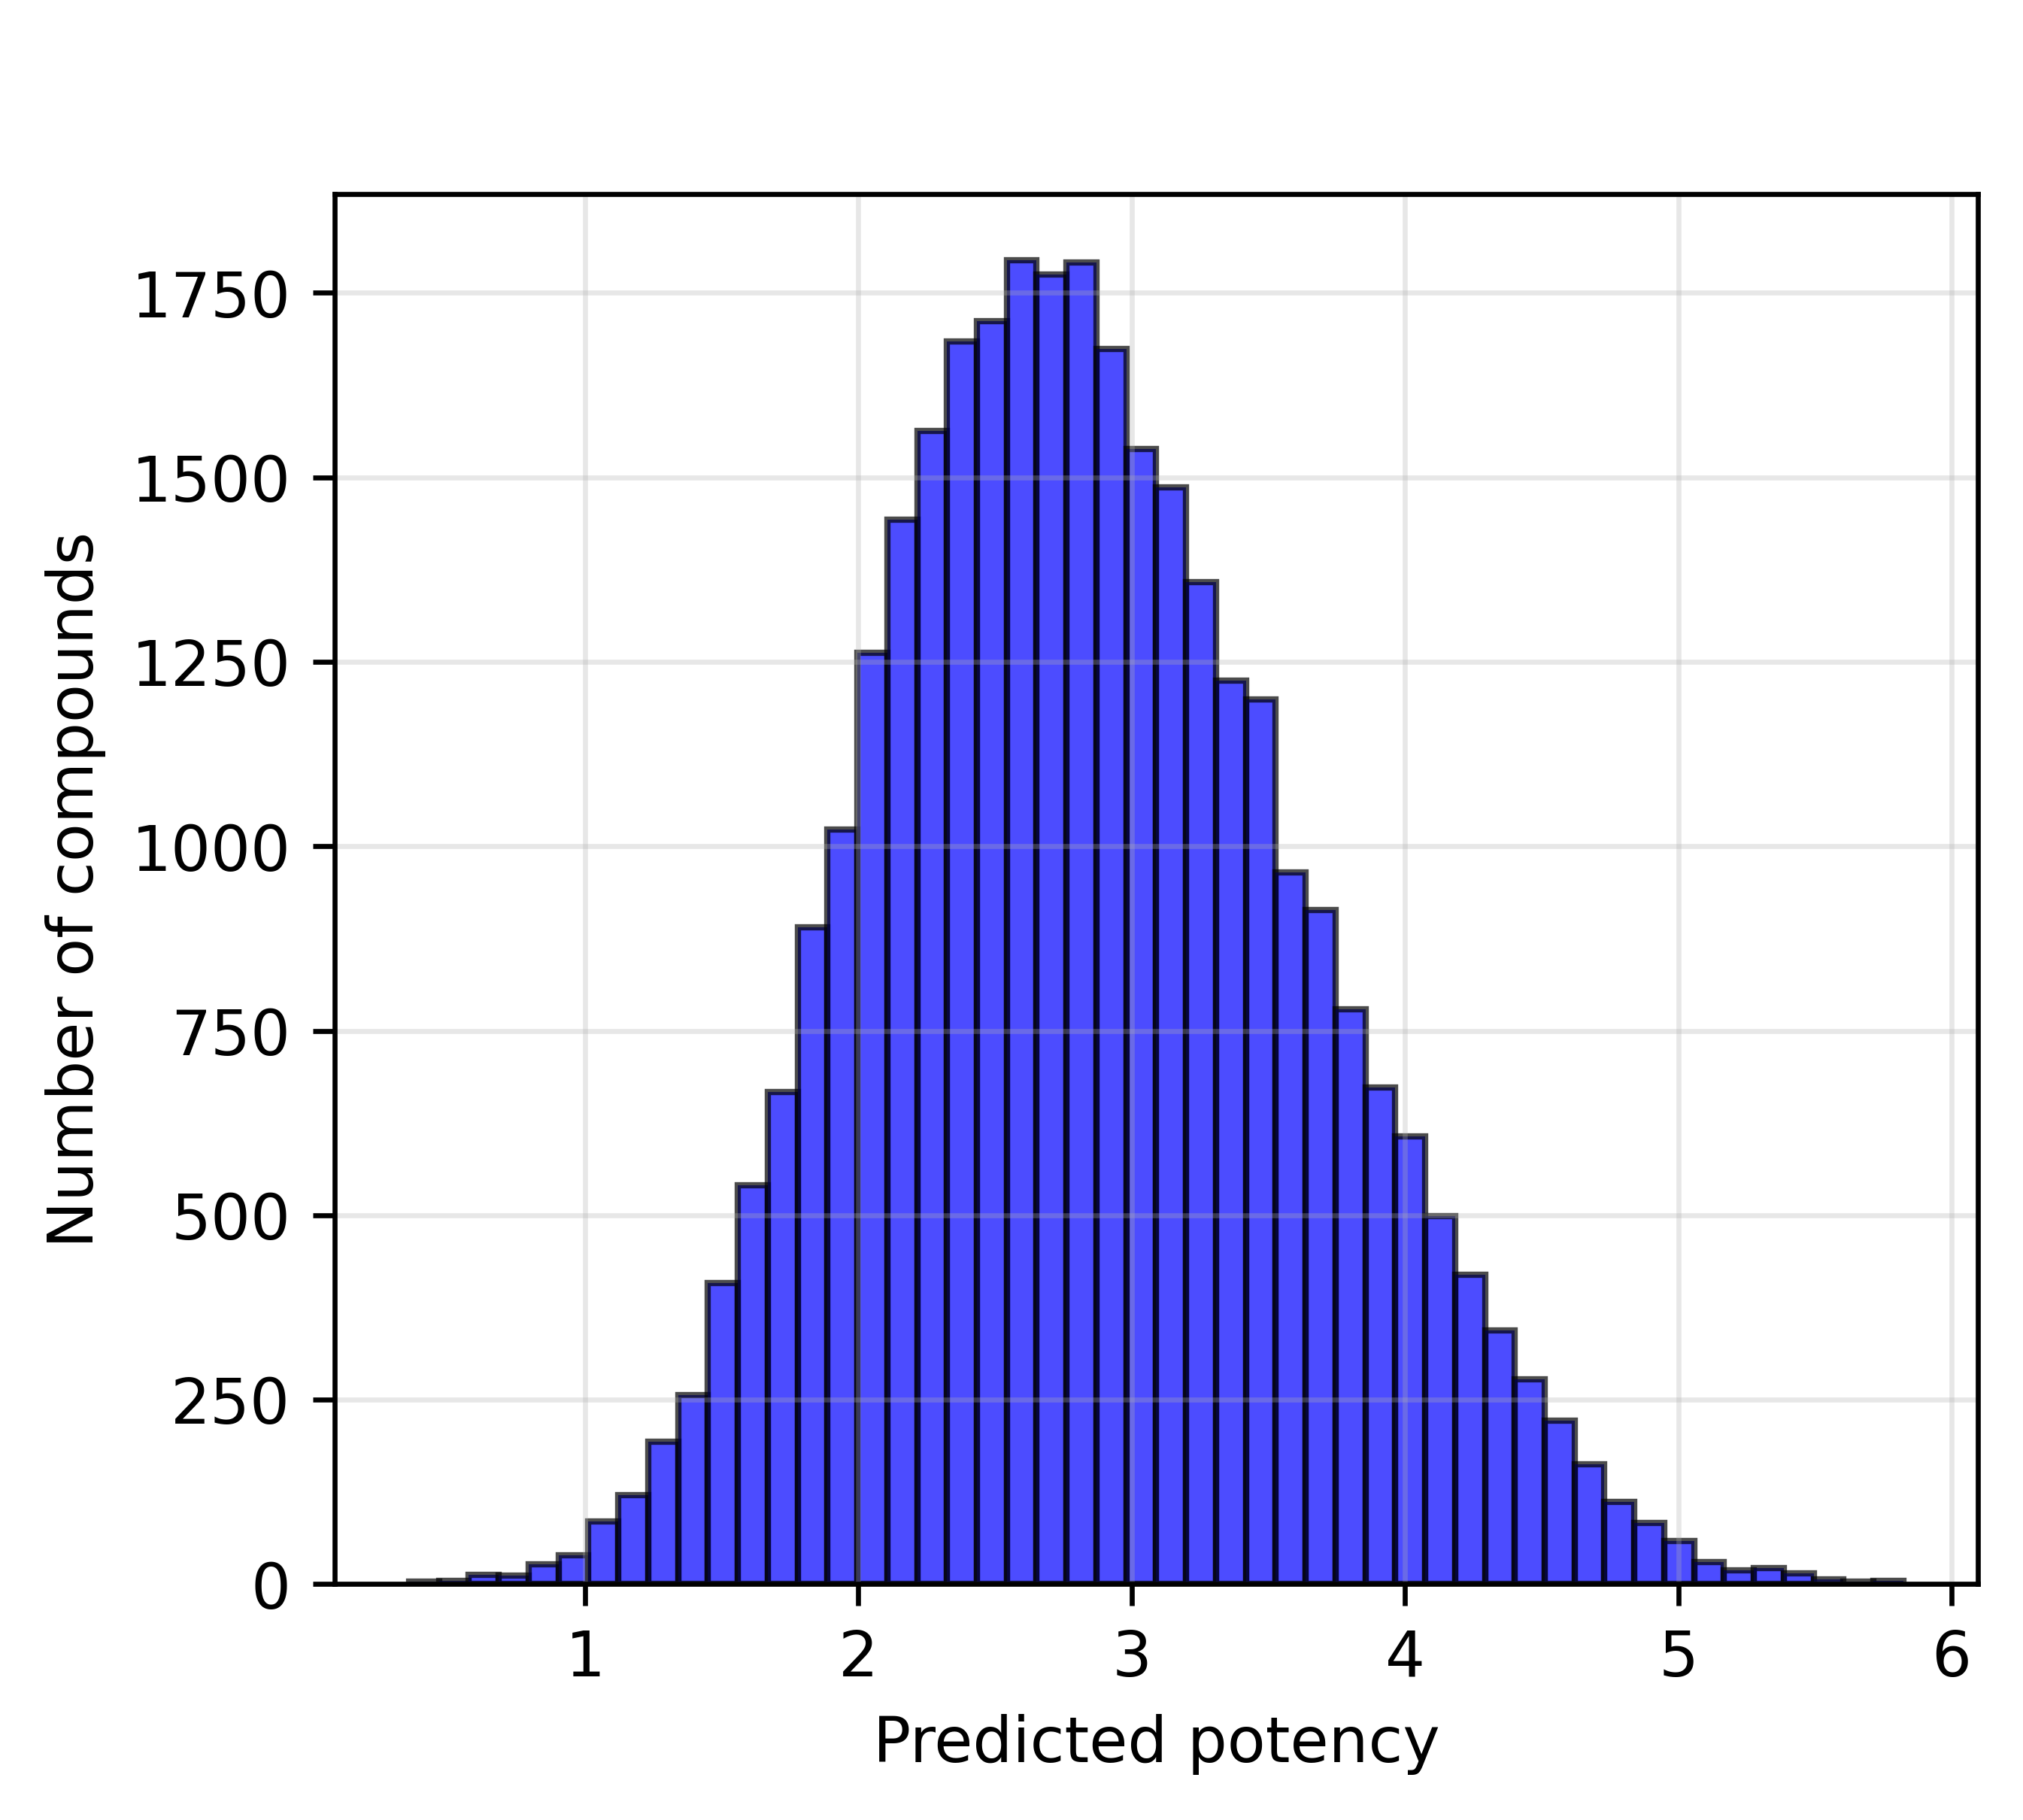

In [222]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2, label='pPotency = 5.0 (minimum)') 
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2, label='pPotency = 6.0 (good)')
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2, label='pPotency = 7.0 (excellent)')

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + '/BacillusAnthracis_noDuplicates_validation.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + '/BacillusAnthracis_noDuplicates_validation.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [223]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 0 compounds
Low priority (5 ≤ pPotency < 6): 132 compounds


In [224]:
EnamineAntibioticData_final = EnamineAntibioticData.iloc[idx].copy()
EnamineAntibioticData_final['pPotency_prediction'] = Y1_lib_pred[idx]

EnamineAntibioticData_final

,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL,pPotency_prediction


### Top 20 compounds with higher pPotency

In [225]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 5.43
Highest predicted pPotency: 5.82
Range of top 20: 5.43 - 5.82


In [226]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
EnamineAntibioticData_top20 = EnamineAntibioticData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
EnamineAntibioticData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
EnamineAntibioticData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
EnamineAntibioticData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("\n Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
EnamineAntibioticData_top20 = EnamineAntibioticData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
EnamineAntibioticData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    5.433
  IC50:        3.690e-06 M  (3689.53 nM)

Best Values (1st ranked compound):
  pPotency:    5.823
  IC50:        1.503e-06 M  (1503.19 nM)

 Range for Top 20 Compounds:
pPotency Range:  5.433 - 5.823

IC50 Range (M):  3.690e-06 - 1.503e-06


,Rank,SMILES,pPotency_prediction,IC50 (M)
27274,1,NC(=O)C1=CN(CC=2C=CC=C(C2)[N+]([O-])=O)N=C1C=3...,5.823,1.503e-06
8327,2,CN(C(=O)C1=CN(C)C=2C(Cl)=CC=CC12)C=3C=CC(=CC3)CN,5.812,1.541e-06
2948,3,Cl.NCCC1=CN(N=C1C=2C=CC(Cl)=CC2)C=3C=CC=CC3,5.722,1.895e-06
16283,4,CN(C=1C=CC=CC1C(N)=O)S(=O)(=O)C=2C=CC=C(C2)S(N...,5.717,1.921e-06
19928,5,[O-][N+](=O)C1=CN(C=CC1=O)CC2=CSC(=N2)C=3C=COC3,5.690,2.040e-06
3323,6,Cl.Cl.COC=1C=CC=C(C1)N2C(CCN)=NC=3C=CC=CC32,5.643,2.278e-06
8858,7,NCC=1C=CC(=CC1)C2=NC(=CS2)C=3C=CC=CC3,5.607,2.470e-06
21926,8,CC=1C=CC=C2C=C3C=NN(C=4C=CC=C(C4)[N+]([O-])=O)...,5.598,2.523e-06
2699,9,Cl.Cl.NCC=1C=CC=C(C1)NC(=O)C=2C=CC=C3C=CC=NC23,5.592,2.557e-06
13380,10,C=CC=1C=CC(=CC1)NC(=O)C=2C=CC(=CC2)CN,5.530,2.954e-06


In [227]:
EnamineAntibioticData_top20.to_csv(os.path.join(resultsDir + "BacillusAnthracis/BacillusAnthracis_noDuplicates_EnamineAntiviralsData_top20.csv"), index=False)
EnamineAntibioticData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "BacillusAnthracis/BacillusAnthracis_noDuplicates_EnamineAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis/BacillusAnthracis_noDuplicates_enamine_predictedCompounds.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis/BacillusAnthracis_noDuplicates_enamine_predictedCompounds.svg


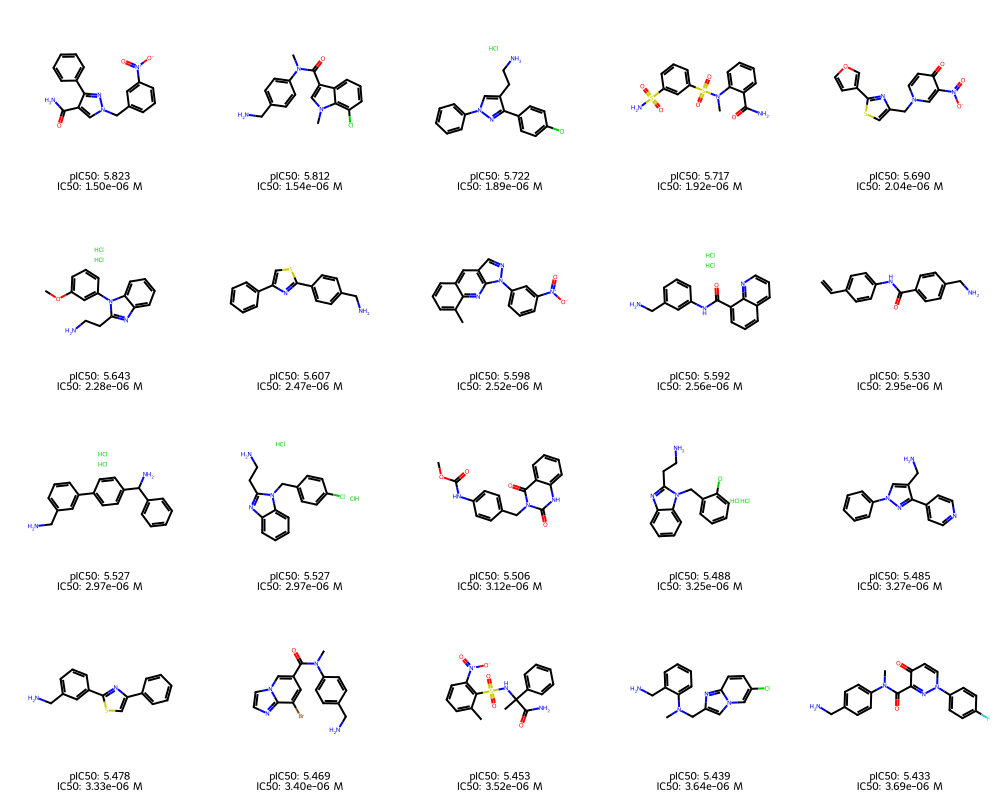

In [228]:
# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntibioticData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in EnamineAntibioticData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + '/BacillusAnthracis_noDuplicates_enamine_predictedCompounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + '/BacillusAnthracis_noDuplicates_enamine_predictedCompounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

### 2.2 Discovery of new hits specific to this bacteria (data source Life chemicals data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. The custom library compiled from commercial catalogs by Life chemicals. In particular, we are interested in molecules with high predicted pPotency.

In [229]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "LifeChemicals/LC_Antibacterial_Focused_Library.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

LCAntibioticData = pd.DataFrame(records)

print(f"Original LifeChemicals data shape: {LCAntibioticData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to LifeChemicals data (reusing canonical_train from code-1)
LCAntibioticData['Canonical_SMILES'] = LCAntibioticData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~LCAntibioticData['Canonical_SMILES'].isin(canonical_train)
LCAntibioticData_filtered = LCAntibioticData[mask].copy()

# Remove the helper column if you don't need it
LCAntibioticData = LCAntibioticData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered LifeChemicals data shape for validation: {LCAntibioticData.shape}")
print(f"Removed {LCAntibioticData_filtered.shape[0] - LCAntibioticData.shape[0]} duplicate compounds from LifeChemicals data set")

# Now use the filtered data
smi_lib = LCAntibioticData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
LCAntibioticData.head()

Original LifeChemicals data shape: (15538, 26)
Number of unique SMILES in training set: 398
Filtered LifeChemicals data shape for validation: (15532, 26)
Removed 0 duplicate compounds from LifeChemicals data set
Total compounds to screen: 15532


,IDNUMBER,Chemical_Name,CAS,PriceCoeff,MW,Description,FSP3,clogP,TPSA,H-acceptors,...,Reference_ID,Activity_type,Activity_value_,Activity_units_,Activity_comment,Target_name,Target_organism,Target_type,SMILES,PPDS
0,F6540-4248,"6-(3-methoxypiperidin-1-yl)-N,N-dimethylpyrimi...",2097927-68-7,1.500,236.310,oil,0.670,1.600,41.490,3,...,CHEMBL4548594,Inhibition,37.210,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,COC1CCCN(c2cc(N(C)C)ncn2)C1,NaN
1,F6541-0830,"1-(5,6,7,8-tetrahydroquinazolin-4-yl)piperidin...",1541766-76-0,1.500,233.310,oil,0.690,1.510,49.250,3,...,CHEMBL4533334,Inhibition,26.560,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,OC1CCCN(c2ncnc3c2CCCC3)C1,NaN
2,F6541-5261,5-fluoro-2-[4-(propan-2-yl)piperazin-1-yl]pyri...,2034458-11-0,1.500,224.280,oil,0.640,1.460,32.260,3,...,CHEMBL4542429,Inhibition,25.160,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,CC(C)N1CCN(c2ncc(F)cn2)CC1,NaN
3,F6543-7286,"6-(2,6-dimethylmorpholin-4-yl)-N,N-dimethylpyr...",2034461-31-7,1.500,236.310,solid,0.670,1.830,41.490,3,...,CHEMBL4548594,Inhibition,37.210,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,CC1CN(c2cc(N(C)C)ncn2)CC(C)O1,NaN
4,F6570-1027,1-[6-(dimethylamino)pyrimidin-4-yl]piperidin-3-ol,1903487-65-9,1.500,222.280,solid,0.640,0.840,52.490,3,...,CHEMBL4548594,Inhibition,37.210,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,CN(C)c1cc(N2CCCC(O)C2)ncn1,NaN


In [230]:
print("\nComputing MACAW embeddings")
X1_lib = mcw.transform(smi_lib)
print(f"Embedding shape: {X1_lib.shape}")


Computing MACAW embeddings
Embedding shape: (15532, 45)


In [231]:
print("Generating predictions")
Y1_lib_pred = regr_pred.predict(X1_lib)
print(f"Predictions shape: {Y1_lib_pred.shape}")

Generating predictions
Predictions shape: (15532,)


In [232]:
LCAntibioticData_predicted = LCAntibioticData.copy()
LCAntibioticData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
LCAntibioticData_predicted['IC50 (M)'] = 10 ** (-LCAntibioticData_predicted['pPotency_prediction'])

LCAntibioticData_predicted = LCAntibioticData_predicted.filter(
    items=["SMILES", "pPotency_prediction", "IC50 (M)"]
)
LCAntibioticData_predicted.to_csv(os.path.join(resultsDir + "BacillusAnthracis/BacillusAnthracis_noDuplicates_LCDatasets_predicted_all.csv"), index=False)
LCAntibioticData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "BacillusAnthracis/BacillusAnthracis_noDuplicates_LCDatasets_predicted_all_SMILES.csv"), index=False)
LCAntibioticData_predicted

,SMILES,pPotency_prediction,IC50 (M)
0,COC1CCCN(c2cc(N(C)C)ncn2)C1,3.435,3.673e-04
1,OC1CCCN(c2ncnc3c2CCCC3)C1,3.207,6.215e-04
2,CC(C)N1CCN(c2ncc(F)cn2)CC1,2.798,1.594e-03
3,CC1CN(c2cc(N(C)C)ncn2)CC(C)O1,3.350,4.462e-04
4,CN(C)c1cc(N2CCCC(O)C2)ncn1,3.413,3.860e-04
...,...,...,...
15533,O=C1c2cccc3cccc(c23)C(=O)N1CCCN(C(=O)c1ccc(-c2...,4.128,7.441e-05
15534,O=C1Nc2ccc(S(=O)(=O)Nc3ccc(NS(=O)(=O)c4ccc5c6c...,3.862,1.375e-04
15535,Cc1ncc(CO)c2cc(C(=O)Nc3cccc4ccccc34)/c(=N/c3cc...,2.037,9.193e-03
15536,CCOC(=O)c1sc(NC(=O)c2ccc(Oc3ccc(C(=O)Nc4nc(-c5...,3.036,9.197e-04


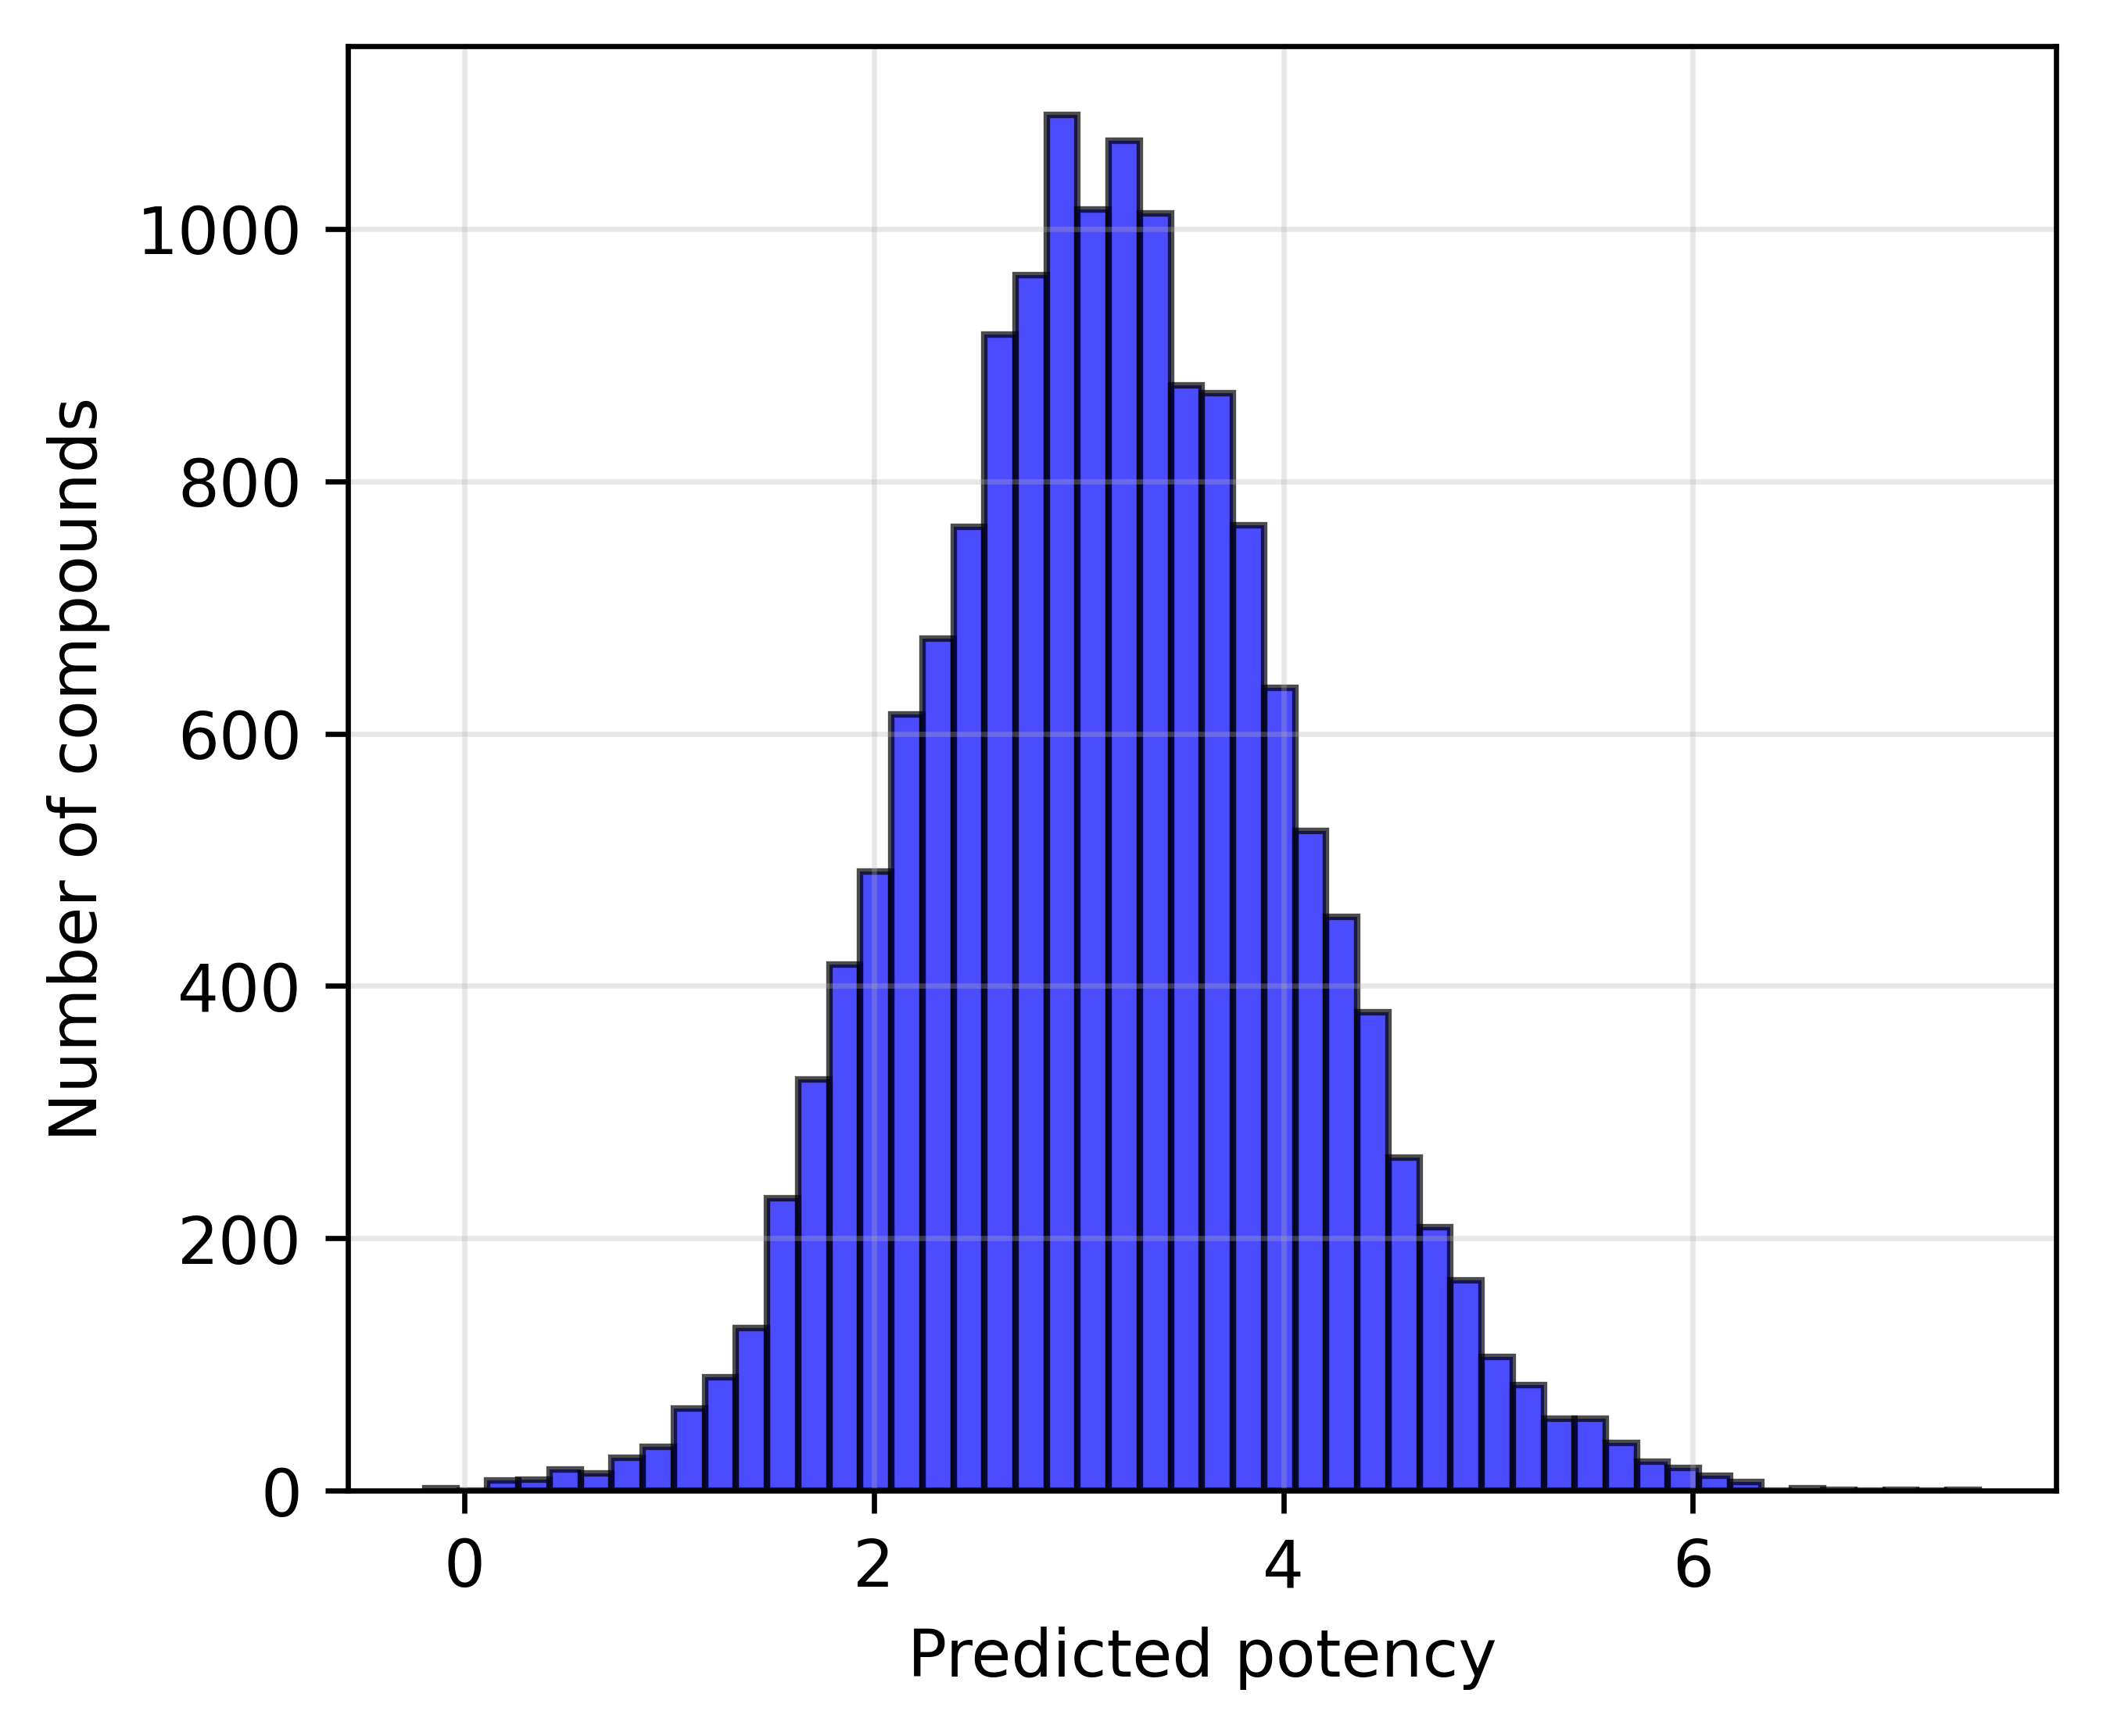

In [233]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + '/BacillusAnthracis_noDuplicates_validationLCDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + '/BacillusAnthracis_noDuplicates_validationLCDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [234]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 1 compounds
Medium priority (6 ≤ pPotency < 7.0): 27 compounds
Low priority (5 ≤ pPotency < 6): 346 compounds


In [235]:
LCAntibioticData_final = LCAntibioticData.iloc[idx].copy()
LCAntibioticData_final['pPotency_prediction'] = Y1_lib_pred[idx]
LCAntibioticData_final = LCAntibioticData_final.filter(
    items=["SMILES", "pPotency_prediction", "clogP"]
)
LCAntibioticData_final

,SMILES,pPotency_prediction,clogP
9818,Cc1cc2ncn(Cc3ccc(Cl)cc3)c2cc1C,7.395,4.760


### Top 20 compounds with higher pPPotency

In [236]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 6.07
Highest predicted pPotency: 7.39
Range of top 20: 6.07 - 7.39


In [237]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
LCAntibioticData_top20 = LCAntibioticData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
LCAntibioticData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
LCAntibioticData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
LCAntibioticData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*50)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*50)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
LCAntibioticData_top20 = LCAntibioticData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
LCAntibioticData_top20

--------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
--------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    6.071
  IC50:        8.501e-07 M  (850.09 nM)

Best Values (1st ranked compound):
  pPotency:    7.395
  IC50:        4.028e-08 M  (40.28 nM)
Range for Top 20 Compounds:
pPotency Range:  6.071 - 7.395

IC50 Range (M):  8.501e-07 - 4.028e-08


,Rank,SMILES,pPotency_prediction,IC50 (M)
9818,1,Cc1cc2ncn(Cc3ccc(Cl)cc3)c2cc1C,7.395,4.028e-08
10587,2,Nc1c(-c2ccc3ccccc3c2)nc2ccccn12,6.961,1.093e-07
9773,3,Cc1cc2ncn(Cc3ccccc3Cl)c2cc1C,6.758,1.746e-07
10300,4,Nc1ccc(N2C(=O)c3cccc4cccc(c34)C2=O)cc1,6.509,3.101e-07
12207,5,c1ccc(Oc2cccc(Oc3ccccc3)c2)cc1,6.508,3.108e-07
9695,6,Cc1nc2ccccc2n1Cc1cccc(Cl)c1,6.301,4.998e-07
9578,7,Cc1cc2ncn(Cc3ccc(F)cc3)c2cc1C,6.269,5.380e-07
15501,8,c1ccc2nc3c4ccccc4c4ccccc4c3nc2c1,6.220,6.022e-07
13080,9,Brc1cccc(-c2nc3ccccc3n2Cc2ccccc2)c1,6.212,6.142e-07
11338,10,Cc1cc(C)cc(-n2c(=O)c3ccccc3c3ccccc3c2=O)c1,6.197,6.350e-07


In [238]:
LCAntibioticData_top20.to_csv(os.path.join(resultsDir + "BacillusAnthracis/BacillusAnthracis_noDuplicates_LCAntiviralsData_top20.csv"), index=False)
LCAntibioticData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "BacillusAnthracis/BacillusAnthracis_noDuplicates_LCAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis/BacillusAnthracis_noDuplicates_predictedCompounds_LCDataset.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis/BacillusAnthracis_noDuplicates_predictedCompounds_LCDataset.svg


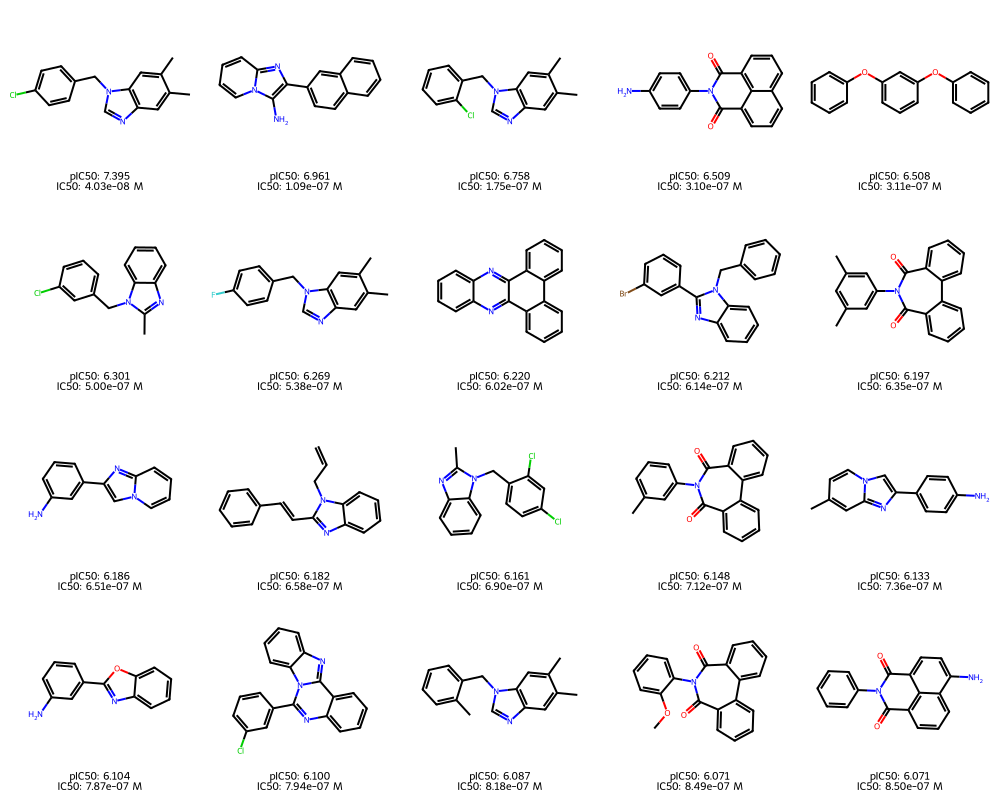

In [239]:
# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in LCAntibioticData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in LCAntibioticData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + '/BacillusAnthracis_noDuplicates_predictedCompounds_LCDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + '/BacillusAnthracis_noDuplicates_predictedCompounds_LCDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img) 

### 2.3 Discovery of new hits specific to all viruses (data source ChemDiv antibiotics)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. The custom library ("ChemDiv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [240]:
supplier = Chem.SDMolSupplier(dataDir + "ChemDiv/ChemDiv_Antibacterial_gramm_negative_12510.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

ChemDivAntiBioticData = pd.DataFrame(records)

print(f"Original ChemDiv data shape: {ChemDivAntiBioticData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to ChemDiv data (reusing canonical_train from previous code)
ChemDivAntiBioticData['Canonical_SMILES'] = ChemDivAntiBioticData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~ChemDivAntiBioticData['Canonical_SMILES'].isin(canonical_train)
ChemDivAntiBioticData_filtered = ChemDivAntiBioticData[mask].copy()

# Remove the helper column if you don't need it
ChemDivAntiBioticData = ChemDivAntiBioticData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered ChemDiv data shape for validation: {ChemDivAntiBioticData.shape}")
print(f"Removed {ChemDivAntiBioticData_filtered.shape[0] - ChemDivAntiBioticData.shape[0]} duplicate compounds from ChemDiv data set")

# Now use the filtered data
smi_lib = ChemDivAntiBioticData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
ChemDivAntiBioticData

Original ChemDiv data shape: (12510, 16)
Number of unique SMILES in training set: 398
Filtered ChemDiv data shape for validation: (12507, 16)
Removed 0 duplicate compounds from ChemDiv data set
Total compounds to screen: 12507


,IDNUMBER,STEREO_COMMENTS,SMILE,LOGP,LOGD,LOGSW,N_ROTB,N_CHIRALS,H_ACCEPTORS,H_DONORS,PSA,WEIGHT_AVAILABLE1,CHEMNAME,SMILES,SALTDATA,SALTDATA_MOLWEIGHT
0,000L-0380,ACHIRAL,[O-][N+](c(cc1)ccc1C(Oc(cc1)ccc1-c1ccccc1)=O)=O,4.934,4.934,-5.149,5.000,0.000e+00,7.000,0.000e+00,53.726,34,"[1,1'-biphenyl]-4-yl 4-nitrobenzoate",O=C(Oc1ccc(-c2ccccc2)cc1)c1ccc([N+](=O)[O-])cc1,NaN,NaN
1,0071-0020,ACHIRAL,Cn(cc1)nc1C(N/N=C/c(cc1)ccc1OC)=O,1.256,1.255,-1.843,5.000,0.000e+00,5.000,1.000,57.790,12,N'-[(4-methoxyphenyl)methylidene]-1-methyl-1H-...,COc1ccc(/C=N/NC(=O)c2ccn(C)n2)cc1,NaN,NaN
2,0080-0039,RACEMIC MIXTURE,CC1(C)OC1COC(c(cc(cco1)c1c1)c1O1)=CC1=O,2.481,2.481,-3.143,3.000,1.000,6.000,0.000e+00,44.076,113,"5-[(3,3-dimethyloxiran-2-yl)methoxy]-7H-furo[3...",CC1(C)OC1COc1cc(=O)oc2cc3occc3cc12,NaN,NaN
3,0083-0046,ACHIRAL,O=C(Cc1ccccc1)c(cc1)ccc1-c1ccccc1,4.779,4.779,-5.194,4.000,0.000e+00,2.000,0.000e+00,12.942,985,"1-([1,1'-biphenyl]-4-yl)-2-phenylethan-1-one",O=C(Cc1ccccc1)c1ccc(-c2ccccc2)cc1,NaN,NaN
4,0089-0027,ACHIRAL,O=C(c1cccc(C(Nc(cc2)ccc2Oc2ccccc2)=O)c1)Nc(cc1...,7.293,7.292,-6.294,10.000,0.000e+00,6.000,2.000,59.916,4,"N~1~,N~3~-bis(4-phenoxyphenyl)benzene-1,3-dica...",O=C(Nc1ccc(Oc2ccccc2)cc1)c1cccc(C(=O)Nc2ccc(Oc...,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12505,Z601-8334,ACHIRAL,Nc1nc(Nc(cccc2)c2F)nc2ccccc12,3.415,3.097,-3.641,2.000,0.000e+00,2.000,3.000,48.570,460,"N~2~-(2-fluorophenyl)quinazoline-2,4-diamine",Nc1nc(Nc2ccccc2F)nc2ccccc12,HCl,36.461
12506,Z601-8612,ACHIRAL,CNc1nc(Nc(cccc2)c2F)nc2ccccc12,4.019,3.229,-4.160,3.000,0.000e+00,2.000,2.000,39.170,841,N~2~-(2-fluorophenyl)-N~4~-methylquinazoline-2...,CNc1nc(Nc2ccccc2F)nc2ccccc12,HCl,36.461
12507,Z601-8674,ACHIRAL,Nc1nc(Nc(cccc2)c2Cl)nc2ccccc12,3.686,3.268,-3.905,2.000,0.000e+00,2.000,3.000,48.570,336,"N~2~-(2-chlorophenyl)quinazoline-2,4-diamine",Nc1nc(Nc2ccccc2Cl)nc2ccccc12,NaN,NaN
12508,Z601-9100,ACHIRAL,CNc1nc(Nc(cccc2)c2Cl)nc2ccccc12,4.290,3.350,-4.279,3.000,0.000e+00,2.000,2.000,39.170,558,N~2~-(2-chlorophenyl)-N~4~-methylquinazoline-2...,CNc1nc(Nc2ccccc2Cl)nc2ccccc12,HCl,36.461


In [241]:
print("\nComputing MACAW embeddings")
X1_lib = mcw.transform(smi_lib)
print(f"Embedding shape: {X1_lib.shape}")


Computing MACAW embeddings
Embedding shape: (12507, 45)


In [242]:
print("Generating predictions")
Y1_lib_pred = regr_pred.predict(X1_lib)
print(f"Predictions shape: {Y1_lib_pred.shape}")

Generating predictions
Predictions shape: (12507,)


In [243]:
ChemDivAntiBioticData_predicted = ChemDivAntiBioticData.copy()
ChemDivAntiBioticData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
ChemDivAntiBioticData_predicted['IC50 (M)'] = 10 ** (-ChemDivAntiBioticData_predicted['pPotency_prediction'])

ChemDivAntiBioticData_predicted = ChemDivAntiBioticData_predicted.filter(
    items=["SMILES", "pPotency_prediction", "IC50 (M)"]
)

ChemDivAntiBioticData_predicted.to_csv(os.path.join(resultsDir + "BacillusAnthracis/BacillusAnthracis_noDuplicates_ChemDivDatasets_predicted_all.csv"), index=False)
ChemDivAntiBioticData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "BacillusAnthracis/BacillusAnthracis_noDuplicates_ChemDivDatasets_predicted_all_SMILES.csv"), index=False)
ChemDivAntiBioticData_predicted

,SMILES,pPotency_prediction,IC50 (M)
0,O=C(Oc1ccc(-c2ccccc2)cc1)c1ccc([N+](=O)[O-])cc1,4.493,3.210e-05
1,COc1ccc(/C=N/NC(=O)c2ccn(C)n2)cc1,3.655,2.216e-04
2,CC1(C)OC1COc1cc(=O)oc2cc3occc3cc12,2.537,2.904e-03
3,O=C(Cc1ccccc1)c1ccc(-c2ccccc2)cc1,4.472,3.374e-05
4,O=C(Nc1ccc(Oc2ccccc2)cc1)c1cccc(C(=O)Nc2ccc(Oc...,4.185,6.529e-05
...,...,...,...
12505,Nc1nc(Nc2ccccc2F)nc2ccccc12,5.316,4.833e-06
12506,CNc1nc(Nc2ccccc2F)nc2ccccc12,4.546,2.842e-05
12507,Nc1nc(Nc2ccccc2Cl)nc2ccccc12,5.163,6.873e-06
12508,CNc1nc(Nc2ccccc2Cl)nc2ccccc12,4.597,2.529e-05


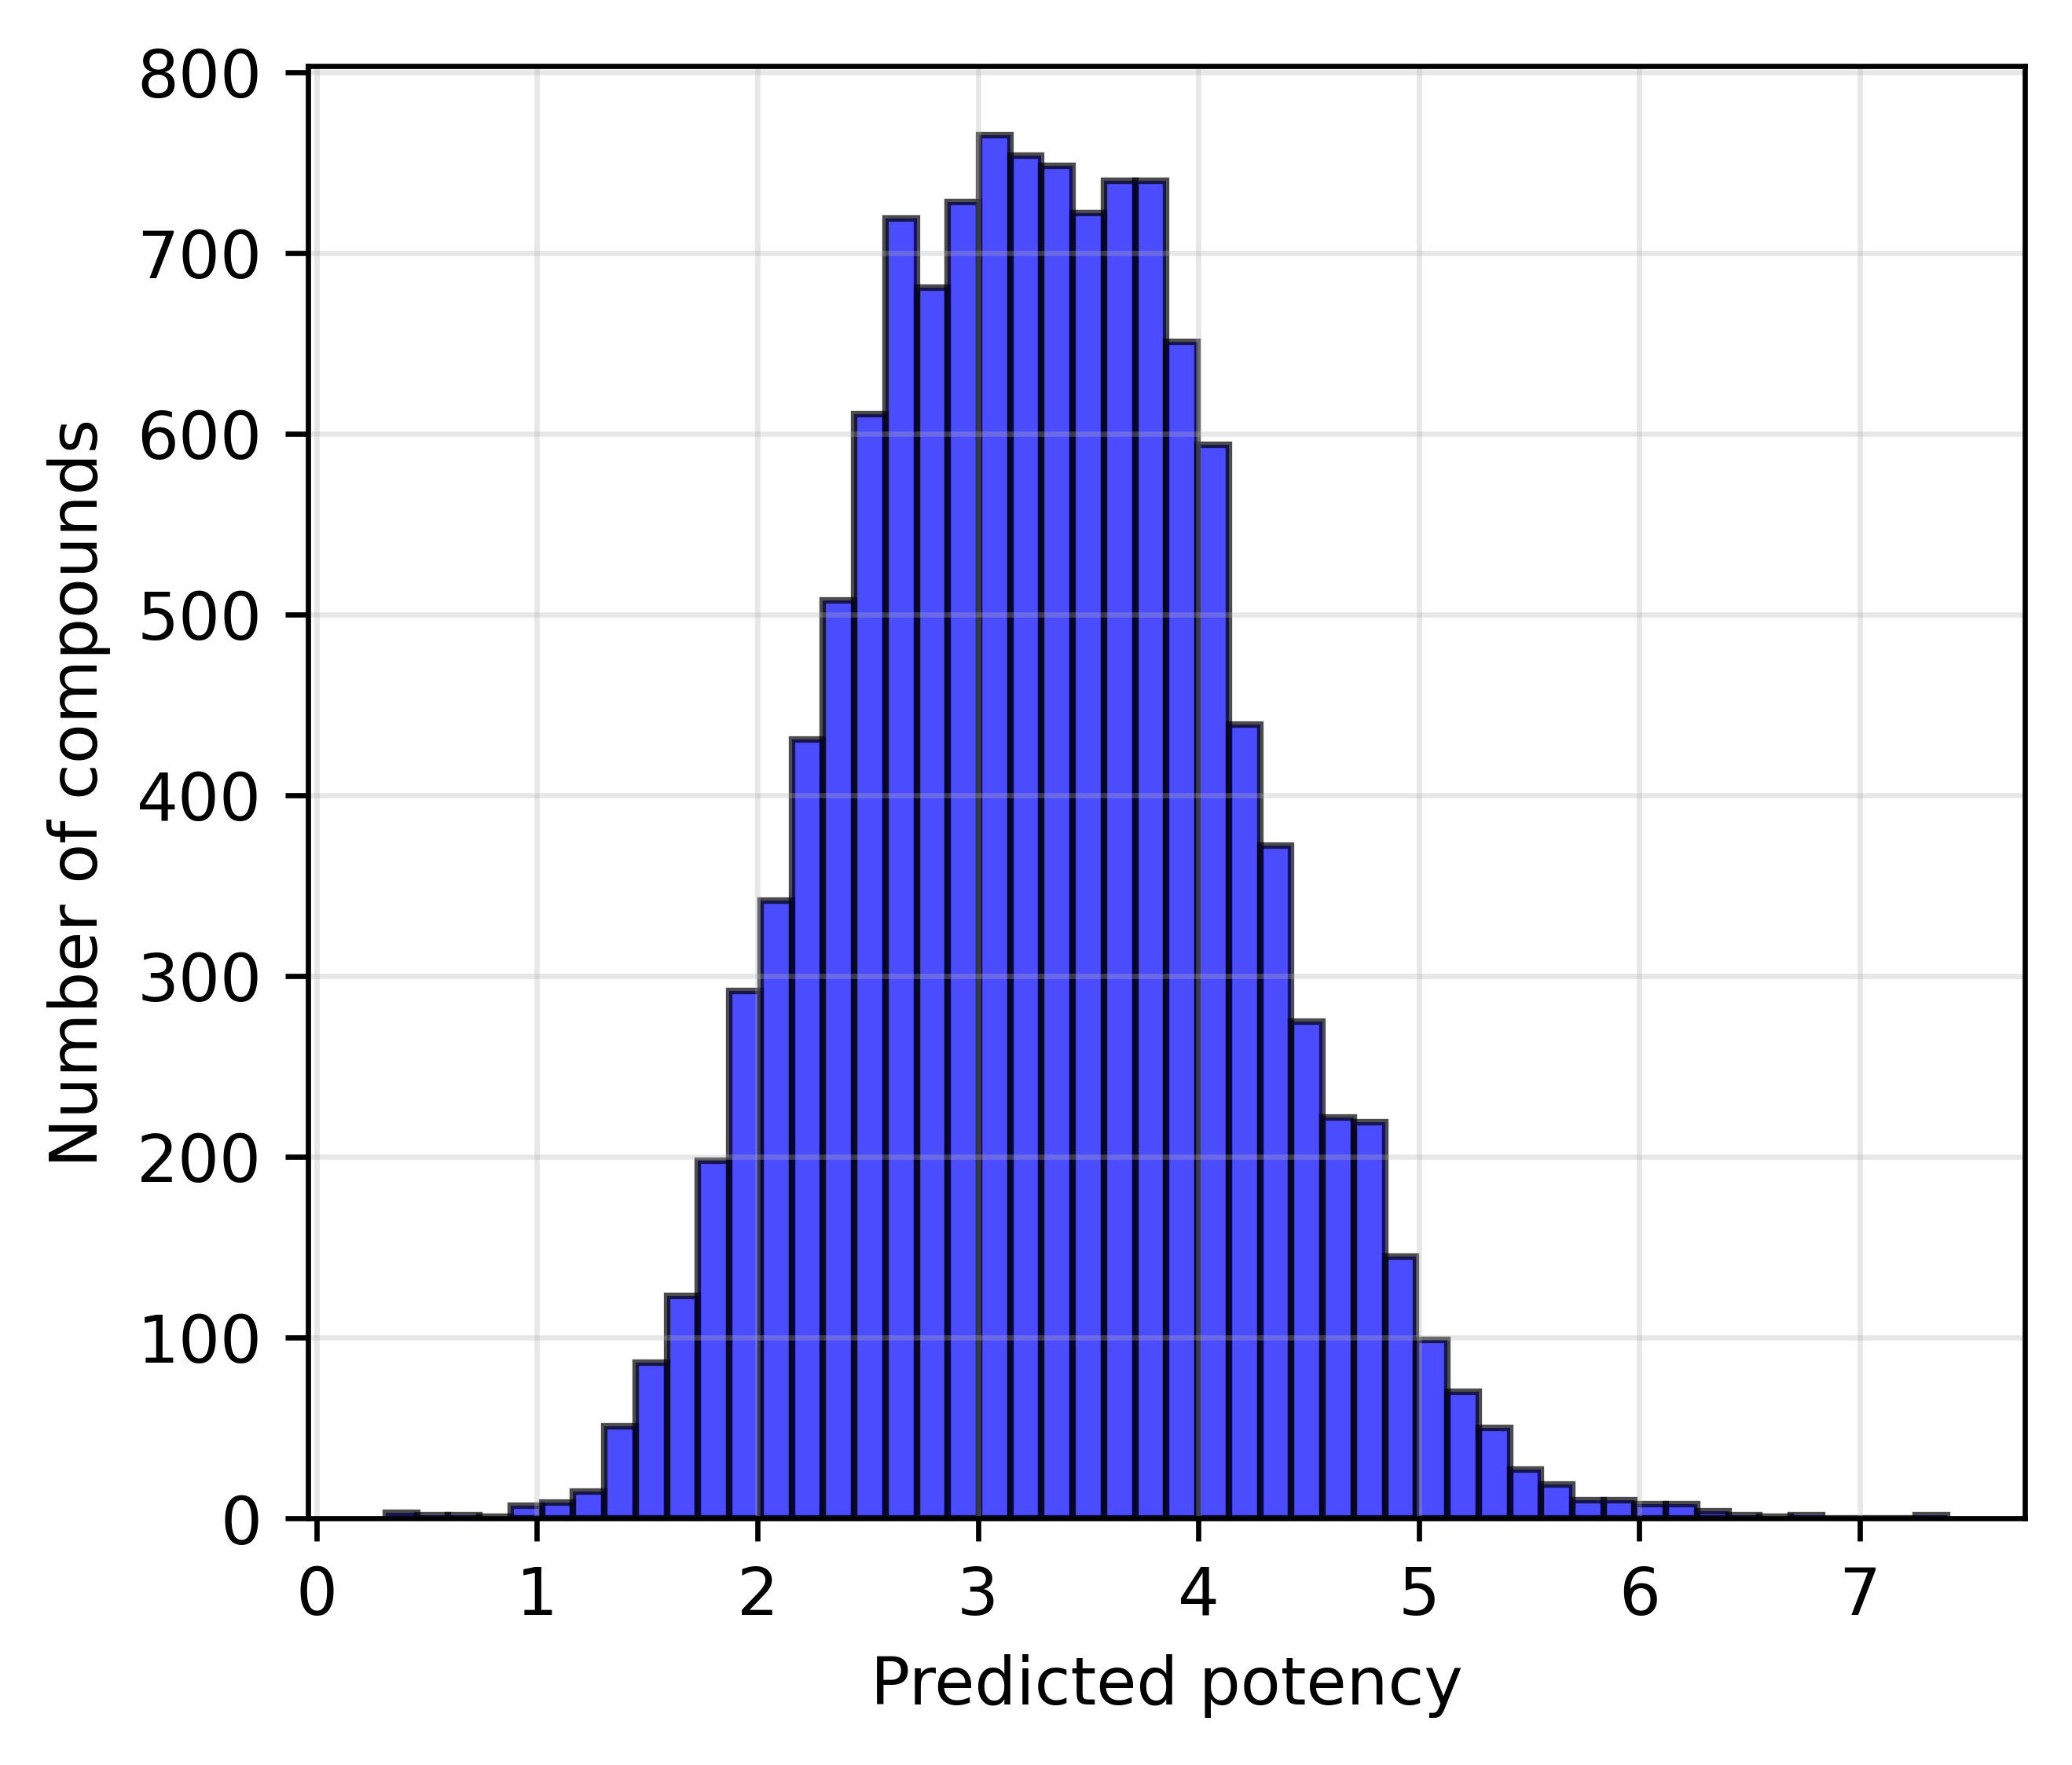

In [244]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + '/BacillusAnthracis_noDuplicates_validationChemDivDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + '/BacillusAnthracis_noDuplicates_validationChemDivDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [245]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 2 compounds
Medium priority (6 ≤ pPotency < 7.0): 23 compounds
Low priority (5 ≤ pPotency < 6): 281 compounds


In [246]:
ChemDivAntiBioticData_final = ChemDivAntiBioticData.iloc[idx].copy()
ChemDivAntiBioticData_final['pPotency_prediction'] = Y1_lib_pred[idx]
ChemDivAntiBioticData_final = ChemDivAntiBioticData_final.filter(
    items=["SMILES", "pPotency_prediction", "clogP"]
)
ChemDivAntiBioticData_final

,SMILES,pPotency_prediction
5790,Cc1cc2ncn(Cc3ccc(Cl)cc3)c2cc1C,7.395
12374,Cc1cc2ncn(Cc3ccc(Cl)cc3Cl)c2cc1C,7.364


### Top 20 compounds with higher pPPotency

In [247]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 6.09
Highest predicted pPotency: 7.39
Range of top 20: 6.09 - 7.39


In [248]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
ChemDivAntiBioticData_top20 = ChemDivAntiBioticData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
ChemDivAntiBioticData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
ChemDivAntiBioticData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
ChemDivAntiBioticData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*50)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*50)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
ChemDivAntiBioticData_top20 = ChemDivAntiBioticData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
ChemDivAntiBioticData_top20

--------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
--------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    6.093
  IC50:        8.073e-07 M  (807.30 nM)

Best Values (1st ranked compound):
  pPotency:    7.395
  IC50:        4.028e-08 M  (40.28 nM)
Range for Top 20 Compounds:
pPotency Range:  6.093 - 7.395

IC50 Range (M):  8.073e-07 - 4.028e-08


,Rank,SMILES,pPotency_prediction,IC50 (M)
5790,1,Cc1cc2ncn(Cc3ccc(Cl)cc3)c2cc1C,7.395,4.028e-08
12374,2,Cc1cc2ncn(Cc3ccc(Cl)cc3Cl)c2cc1C,7.364,4.325e-08
172,3,c1ccc(-c2cc(-c3ccccc3)n(-c3ccccc3)n2)cc1,6.776,1.673e-07
5789,4,Cc1cc2ncn(Cc3ccccc3Cl)c2cc1C,6.758,1.746e-07
12379,5,Cc1cc2nc(C)n(Cc3cccc(Cl)c3)c2cc1C,6.671,2.135e-07
12372,6,Clc1ccc(Cn2c(-c3ccccc3)nc3ccccc32)cc1,6.501,3.157e-07
5803,7,Cc1ccc(Cn2cnc3cc(C)c(C)cc32)cc1,6.435,3.669e-07
3741,8,COc1cccc2c1OC1(C=C2)c2ccccc2-c2ccccc2N1C,6.395,4.030e-07
12371,9,Clc1ccccc1Cn1c(-c2ccccc2)nc2ccccc21,6.393,4.049e-07
5827,10,Cc1nc2ccccc2n1Cc1cccc(Cl)c1,6.301,4.998e-07


In [249]:
ChemDivAntiBioticData_top20.to_csv(os.path.join(resultsDir + "BacillusAnthracis/BacillusAnthracis_noDuplicates_ChemDivAntiviralsData_top20.csv"), index=False)
ChemDivAntiBioticData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "BacillusAnthracis/BacillusAnthracis_noDuplicates_ChemDivAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis/BacillusAnthracis_noDuplicates_predictedCompounds_ChemDivDataset.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis/BacillusAnthracis_noDuplicates_predictedCompounds_ChemDivDataset.svg


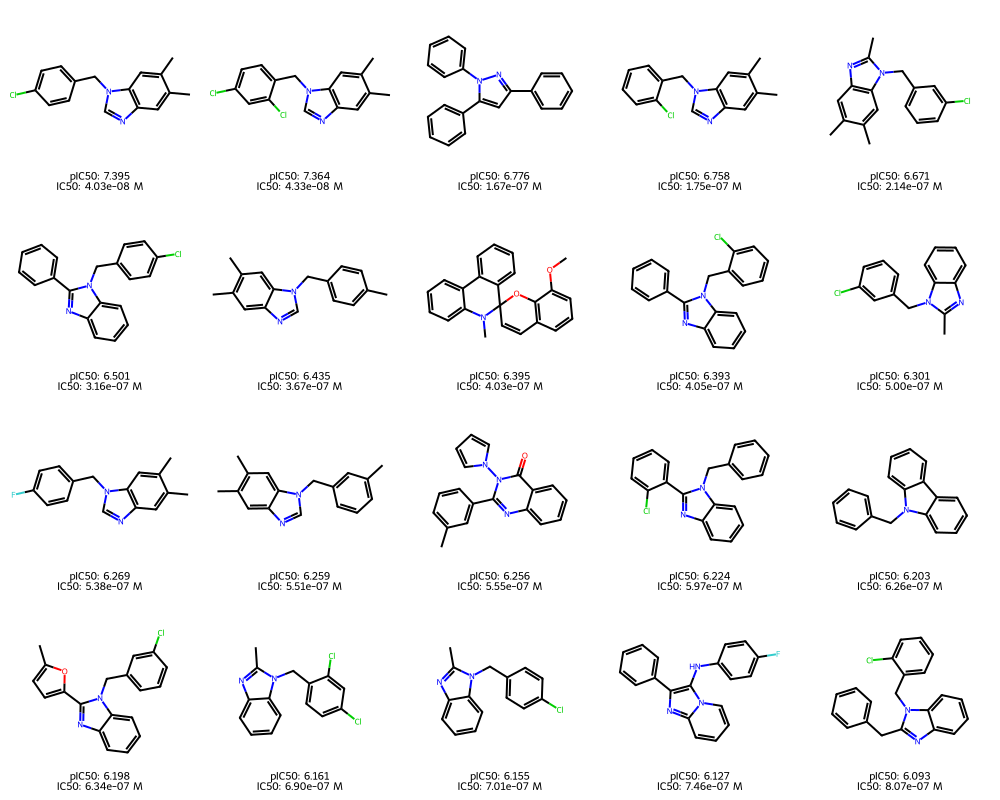

Partition 1/10
  Fold 1 - Train MAE: 1.17, Test MAE: 1.76
Partition 8/10
  Fold 8 - Train MAE: 1.19, Test MAE: 1.68
Partition 2/10
  Fold 2 - Train MAE: 1.34, Test MAE: 1.59
Partition 5/10
  Fold 5 - Train MAE: 1.37, Test MAE: 1.62
Partition 9/10
  Fold 9 - Train MAE: 1.77, Test MAE: 2.14
Partition 3/10
  Fold 3 - Train MAE: 1.21, Test MAE: 1.29
Partition 6/10
  Fold 6 - Train MAE: 1.29, Test MAE: 1.44
Partition 10/10
  Fold 10 - Train MAE: 1.28, Test MAE: 1.47
Partition 1/10
  Fold 1 - Train MAE: 1.38, Test MAE: 1.38
Partition 7/10
  Fold 7 - Train MAE: 1.37, Test MAE: 1.66
Partition 2/10
  Fold 2 - Train MAE: 1.30, Test MAE: 1.22
Partition 5/10
  Fold 5 - Train MAE: 1.28, Test MAE: 1.51
Partition 9/10
  Fold 9 - Train MAE: 1.20, Test MAE: 1.59
Partition 4/10
  Fold 4 - Train MAE: 1.35, Test MAE: 1.61
Partition 6/10
  Fold 6 - Train MAE: 1.34, Test MAE: 1.89
Partition 10/10
  Fold 10 - Train MAE: 1.83, Test MAE: 1.66
Partition 4/10
  Fold 4 - Train MAE: 1.22, Test MAE: 1.38
Partition 

In [250]:
# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in ChemDivAntiBioticData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in ChemDivAntiBioticData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + '/BacillusAnthracis_noDuplicates_predictedCompounds_ChemDivDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + '/BacillusAnthracis_noDuplicates_predictedCompounds_ChemDivDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img) 